# EDA roadmap - foundational questions

One quarter of data, 7,043 customers, ~26.5% churned. `Quarter` is a constant in the
source, so **there is no time dimension**: every question below is cross-sectional.
"Churn over time" can only be approached through `tenure_in_months` as a proxy for
lifecycle stage, never as a trend.

Ground rules for every cut below:
- report the **base rate (26.5%) alongside every segment rate** - a segment is only
  interesting relative to it
- report **n per segment**, and treat anything under ~100 customers as directional only
- distinguish **churn rate** (risk within a segment) from **share of churners**
  (where the volume sits). The age finding already shows these disagree.

---






## 4. Price and perceived value

- Churn rate across `monthly_charge` deciles. Is the relationship monotonic?
- Charge per service held: does a customer paying a lot *for little* churn more than one
  paying a lot for a lot? (Derive a services count from the boolean flags.)
- Do `total_refunds` and `total_extra_data_charges` > 0 mark unhappy customers?
- `total_charges` is mostly tenure x price - check it is not just re-telling section 2.

## 7. Geography

- Churn rate by `city` - top and bottom 10 by rate, with n shown. How much of the spread
  is real and how much is small-sample noise?
- Is there a relationship between zip `population` (density proxy) and churn? Urban
  markets have more competitor choice.
- Do the high-churn cities concentrate in one `churn_category`?

## 8. Acquisition - offers and referrals

- Churn rate by `offer` ('offer a'-'offer e', 'none'). Which offers bought loyalty and
  which bought a customer who left anyway?
- Careful: offers are not randomly assigned. Are they concentrated in particular tenure
  or contract groups?
- Does `referred_a_friend` / `number_of_referrals` predict retention? Referrers are
  usually the most engaged customers.

## 9. Stated reasons - what the churners say

- Breakdown of `churn_category` and the top `churn_reason` values. How much is
  competitor-driven vs price vs service vs attitude?
- Which categories are **addressable**? Competitor offers and price are commercial
  levers; "attitude of support person" is an operational one.
- Does the reason mix differ by segment - do seniors, fiber customers, or month-to-month
  customers leave for different reasons?

## 10. Value at risk

- Churn rate weighted by `cltv` and by `monthly_charge`: which segment holds the most
  *revenue* at risk, as opposed to the most customers?
- Is churn concentrated among low-value customers (cheap to lose) or high-value ones?
- Sanity-check `cltv` first - is it a source-supplied prediction rather than an observed
  value? If so, treat it as a vendor artefact, not ground truth.

## 11. Leakage - what cannot be used to predict

Everything in `stg_telco__status` is recorded with or after the outcome:

- `satisfaction_score` and `churn_score` - confirm they separate churners almost
  perfectly. That near-perfection is the tell that they are unusable as features.
- `churn_reason` / `churn_category` - null unless the customer churned; useful for
  *explaining* churn, never for predicting it.
- `customer_status` - another encoding of the target.
- `total_revenue` is derived from the other charge columns, so it is redundant rather
  than leaky.
- Which columns remain that would be known **before** the customer churned? That set is
  the real feature space.

## 12. Before concluding anything

- Every headline finding: does it hold inside tenure and contract buckets, or does it
  disappear? (The age finding is the first candidate for this test.)
- Is any finding driven by a segment of fewer than ~100 customers?
- Which two or three findings would actually change what the business does - and what
  would the recommended action be?


In [1]:
import contextlib
import io
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2, chi2_contingency
from statsmodels.stats.contingency_tables import StratifiedTable, Table2x2
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportion_confint,
    proportions_ztest,
)

In [2]:
def run_query(query):
    df = client.query(query).to_dataframe()
    return df


def compare(k1, n1, k2, n2, label1="group", label2="reference"):
    p1, p2 = k1 / n1, k2 / n2
    ci1 = proportion_confint(k1, n1, method="wilson")
    ci2 = proportion_confint(k2, n2, method="wilson")
    d_ci = confint_proportions_2indep(k1, n1, k2, n2, compare="diff", method="newcomb")
    t = Table2x2(np.array([[k1, n1 - k1], [k2, n2 - k2]]))
    rr_ci = t.riskratio_confint()

    print(
        f"{label1}:   {p1 * 100:.1f}%  ({ci1[0] * 100:.1f}, {ci1[1] * 100:.1f})   n={n1}"
    )
    print(
        f"{label2}:   {p2 * 100:.1f}%  ({ci2[0] * 100:.1f}, {ci2[1] * 100:.1f})   n={n2}"
    )
    print(
        f"diff:    {(p1 - p2) * 100:.1f}pp ({d_ci[0] * 100:.1f}, {d_ci[1] * 100:.1f})"
    )
    print(f"ratio:   {t.riskratio:.2f}x ({rr_ci[0]:.2f}, {rr_ci[1]:.2f})")


def compare_groups(data, reference=None, floor=100, method="newcomb"):
    """
    data: dict of {label: (churners, customers)}
    reference: label to compare against. Defaults to the lowest-rate group.
    """
    labels = list(data)
    rates = {g: data[g][0] / data[g][1] for g in labels}

    if reference is None:
        reference = min(rates, key=rates.get)

    k0, n0 = data[reference]
    p0 = rates[reference]

    counts = np.array([[data[g][0], data[g][1] - data[g][0]] for g in labels])
    chi2, p_omnibus, dof, _ = chi2_contingency(counts)

    rows, pvals = [], []
    for g in labels:
        k, n = data[g]
        p = rates[g]
        ci = proportion_confint(k, n, method="wilson")
        row = {
            "group": g,
            "n": n,
            "churners": k,
            "rate": round(p * 100, 1),
            "ci_lo": round(ci[0] * 100, 1),
            "ci_hi": round(ci[1] * 100, 1),
            "thin": n < floor,
        }
        if g == reference:
            row.update(
                diff=None, diff_lo=None, diff_hi=None, ratio=None, excess=None, p=None
            )
            pvals.append(np.nan)
        else:
            d_ci = confint_proportions_2indep(
                k, n, k0, n0, compare="diff", method=method
            )
            t = Table2x2(np.array([[k, n - k], [k0, n0 - k0]]))
            _, pv = proportions_ztest(np.array([k, k0]), np.array([n, n0]))
            row.update(
                diff=round((p - p0) * 100, 1),
                diff_lo=round(d_ci[0] * 100, 1),
                diff_hi=round(d_ci[1] * 100, 1),
                ratio=round(t.riskratio, 2),
                excess=round(n * (p - p0)),
                p=pv,
            )
            pvals.append(pv)
        rows.append(row)

    df = pd.DataFrame(rows)
    mask = ~np.isnan(pvals)
    if mask.sum() > 1:
        adj = multipletests(np.array(pvals)[mask], method="holm")[1]
        df.loc[mask, "p_adj"] = adj
    else:
        df["p_adj"] = df["p"]

    print(
        f"reference: {reference}   omnibus chi2={chi2:.1f}, "
        f"dof={dof}, p={p_omnibus:.2e}\n"
    )
    return df.sort_values("rate")

def kitagawa(df, group, strata, n, k, a, b):
    """
    Decompose the rate gap between groups a and b into
    within-stratum (rate) and composition (mix) effects.

    df: one row per group x stratum with counts n (customers) and k (churners)
    """
    d = df.copy()
    d["rate"] = d[k] / d[n]
    d["share"] = d[n] / d.groupby(group)[n].transform("sum")

    w = d.pivot(index=strata, columns=group, values=["rate", "share"])
    ra, rb = w["rate"][a], w["rate"][b]
    sa, sb = w["share"][a], w["share"][b]

    rate_eff = ((sa + sb) / 2 * (ra - rb)).sum()
    comp_eff = ((ra + rb) / 2 * (sa - sb)).sum()
    total = (sa * ra).sum() - (sb * rb).sum()

    return {
        "rate_a": round((sa * ra).sum() * 100, 1),
        "rate_b": round((sb * rb).sum() * 100, 1),
        "gap_pp": round(total * 100, 1),
        "rate_effect_pp": round(rate_eff * 100, 1),
        "composition_pp": round(comp_eff * 100, 1),
        "composition_share": round(comp_eff / total, 2),
    }


def band(values, levels):
    """Put a band column in reading order so grid rows/columns sort naturally."""
    return pd.Categorical(values, levels, ordered=True)


def rate_grid(df, rows, cols, n="customers", k="churners", thin=100, title=None,
              shares=True):
    """
    Churn-rate grid for a two-way cut: one line per `rows` level, one column
    per `cols` level. Cells read `rate% (n)`; `*` flags a cell thinner than
    `thin`. Margins are the pooled rate of that row / column, so every cell
    can be read against its own margin and against the base rate in the header.

    With `shares`, two companion grids follow:
      - customer mix: each column sums to 100, i.e. how that group spreads
        across the strata. This is the mix a stratified comparison holds
        constant, and the bottom line gives each group's share of the base.
      - share of churners: the whole grid sums to 100, so a high-rate cell
        holding few customers shows up as the small volume it is.
    """
    N = df.pivot_table(index=rows, columns=cols, values=n, aggfunc="sum", fill_value=0).astype(float)
    K = df.pivot_table(index=rows, columns=cols, values=k, aggfunc="sum", fill_value=0).astype(float)
    R = K / N.replace(0, np.nan)

    colnames = list(N.columns)
    w = max(13, max(len(str(c)) for c in colnames) + 2)
    lab_w = max(max(len(str(i)) for i in N.index), len(rows)) + 2
    tot_n, tot_k = N.values.sum(), K.values.sum()
    base = tot_k / tot_n

    def block(subtitle, cell, row_margin, col_margin, corner, margin_label="all"):
        head = f"{rows:<{lab_w}}" + "".join(f"{str(c):>{w - 1}} " for c in colnames)
        rule = "-" * (len(head) + 3 + w)
        print(f"\n{subtitle}\n")
        print(head + f"{'|':>3} {margin_label:>{w - 2}} ")
        print(rule)
        for i in N.index:
            cells = "".join(f"{cell(i, c):>{w}}" for c in colnames)
            print(f"{str(i):<{lab_w}}" + cells + f"{'|':>3} {row_margin(i):>{w - 2}} ")
        print(rule)
        cells = "".join(f"{col_margin(c):>{w}}" for c in colnames)
        print(f"{margin_label:<{lab_w}}" + cells + f"{'|':>3} {corner():>{w - 2}} ")

    def rate_txt(kk, nn):
        return (f"{kk / nn * 100:.1f} ({int(nn):,})" if nn else "-") + ("*" if 0 < nn < thin else " ")

    print(f"{title or f'churn rate: {cols} x {rows}'}   |   base {base * 100:.1f}%"
          f"   |   {int(tot_n):,} customers, {int(tot_k):,} churners")
    block(
        f"churn rate: rate% (n)   * = n<{thin}",
        lambda i, c: rate_txt(K.loc[i, c], N.loc[i, c]),
        lambda i: rate_txt(K.loc[i].sum(), N.loc[i].sum()).strip(),
        lambda c: rate_txt(K[c].sum(), N[c].sum()),
        lambda: rate_txt(tot_k, tot_n).strip(),
    )
    if not shares:
        return
    block(
        "customer mix %: each column sums to 100 (how the group spreads across "
        f"{rows}); last line = share of all customers",
        lambda i, c: f"{N.loc[i, c] / N[c].sum() * 100:.1f} ",
        lambda i: f"{N.loc[i].sum() / tot_n * 100:.1f} ",
        lambda c: f"{N[c].sum() / tot_n * 100:.1f} ",
        lambda: f"{100.0:.1f} ",
        margin_label="all",
    )
    block(
        "share of all churners %: the grid sums to 100 (where the volume sits)",
        lambda i, c: f"{K.loc[i, c] / tot_k * 100:.1f} ",
        lambda i: f"{K.loc[i].sum() / tot_k * 100:.1f} ",
        lambda c: f"{K[c].sum() / tot_k * 100:.1f} ",
        lambda: f"{100.0:.1f} ",
        margin_label="all",
    )


def stratified(df, group, strata, a, b, n="customers", k="churners", thin=100):
    """
    Compare group `a` against group `b` inside every level of `strata`, i.e.
    ask whether the a-vs-b gap survives holding `strata` constant.

    Prints, in order:
      - per stratum: the two rates, the share of each group's customers sitting
        in that stratum (`mix`, what makes the strata a confounder at all), and
        the gap in points with a 95% CI and a risk ratio
      - the Mantel-Haenszel pooled effect: the gap with `strata` held constant
      - a homogeneity test: is that one effect, or does it change by stratum
      - the Kitagawa split of the crude gap into a real gap and a mix effect
    """
    N = df.pivot_table(index=strata, columns=group, values=n, aggfunc="sum", fill_value=0).astype(float)
    K = df.pivot_table(index=strata, columns=group, values=k, aggfunc="sum", fill_value=0).astype(float)
    lab_w = max(max(len(str(i)) for i in N.index), len(strata)) + 2
    na_tot, nb_tot = N[a].sum(), N[b].sum()

    print(f"\n{a}  vs  {b}   holding {strata} constant")
    print(f"mix% = share of that group's customers sitting in the stratum\n")
    print(f"{strata:<{lab_w}}{a[:12]:>13}{b[:12]:>13}{'mix ' + a[:9]:>14}"
          f"{'mix ' + b[:9]:>14}{'diff pp (95% CI)':>26}{'ratio':>9}{'n':>12}")
    rule = "-" * (lab_w + 101)
    print(rule)

    tables = []
    for i in N.index:
        ka, na, kb, nb = K.loc[i, a], N.loc[i, a], K.loc[i, b], N.loc[i, b]
        if min(na, nb) == 0:
            continue
        tables.append(np.array([[ka, na - ka], [kb, nb - kb]]))
        pa, pb = ka / na, kb / nb
        lo, hi = confint_proportions_2indep(ka, na, kb, nb, compare="diff", method="newcomb")
        # a zero churner cell makes the ratio meaningless - report the gap only
        rr = (f"{Table2x2(np.array([[ka, na - ka], [kb, nb - kb]])).riskratio:.2f}x"
              if min(ka, kb) else "n/a")
        print(f"{str(i):<{lab_w}}{pa * 100:>13.1f}{pb * 100:>13.1f}"
              f"{na / na_tot * 100:>14.1f}{nb / nb_tot * 100:>14.1f}"
              f"{f'{(pa - pb) * 100:+.1f} ({lo * 100:+.1f}, {hi * 100:+.1f})':>26}"
              f"{rr:>9}{f'{int(na + nb):,}':>12}" + ("  *" if min(na, nb) < thin else ""))

    st = StratifiedTable(tables)
    or_lo, or_hi = st.oddsratio_pooled_confint()
    hom = st.test_equal_odds()
    crude = kitagawa(df, group=group, strata=strata, n=n, k=k, a=a, b=b)

    print(rule)
    print(f"{'pooled (MH)':<{lab_w}}{'':>54}"
          f"{f'OR {st.oddsratio_pooled:.2f} ({or_lo:.2f}, {or_hi:.2f})':>26}"
          f"{f'{st.riskratio_pooled:.2f}x':>9}{f'{int(na_tot + nb_tot):,}':>12}")
    print(f"{'homogeneity':<{lab_w}}p={hom.pvalue:.3f}  " + (
        f"-> one common effect, {strata} does not change it" if hom.pvalue > 0.05
        else f"-> the effect genuinely differs across {strata}"))
    print(f"\ncrude gap  {crude['rate_a']}% - {crude['rate_b']}% = {crude['gap_pp']}pp"
          f"  =  {crude['rate_effect_pp']}pp real gap"
          f"  +  {crude['composition_pp']}pp different {strata} mix"
          f"   ({crude['composition_share'] * 100:.0f}% of the gap is mix)")


def plot_grid(df, rows, cols, n="customers", k="churners", title=None, ax=None):
    """Same grid as bars: `rows` on the x axis, one bar per `cols` level, base rate dashed."""
    N = df.pivot_table(index=rows, columns=cols, values=n, aggfunc="sum", fill_value=0).astype(float)
    K = df.pivot_table(index=rows, columns=cols, values=k, aggfunc="sum", fill_value=0).astype(float)
    R = (K / N.replace(0, np.nan)) * 100
    base = K.values.sum() / N.values.sum() * 100

    ax = ax or plt.subplots(figsize=(9, 4.2))[1]
    x = np.arange(len(R.index))
    width = 0.8 / len(R.columns)
    for j, c in enumerate(R.columns):
        pos = x - 0.4 + width * (j + 0.5)
        ax.bar(pos, R[c].values, width * 0.9, label=str(c))
        for pb, v, nn in zip(pos, R[c].values, N[c].values):
            if nn:
                ax.text(pb, v + 0.8, f"{v:.0f}", ha="center", fontsize=8)
    ax.axhline(base, ls="--", lw=1, color="grey")
    ax.text(len(x) - 0.45, base + 0.8, f"base {base:.1f}%", fontsize=8, color="grey", ha="right")
    ax.set_xticks(x, [str(i) for i in R.index])
    ax.set_xlabel(rows)
    ax.set_ylabel("churn rate %")
    ax.set_title(title or f"churn rate: {cols} x {rows}")
    ax.legend(title=cols, frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    return ax


def standardize(df, group, strata, n="customers", k="churners", reference=None):
    """
    Direct standardization: what each group's churn rate would be if every group
    carried the same `strata` mix. The weights are the pooled customer mix, so
    the standardized rates are the crude rates with the composition effect that
    Kitagawa prices removed, and the remaining gap is the rate effect alone.

    CIs are Wald on the weighted sum, var = sum w_i^2 p_i(1-p_i)/n_i.
    """
    N = df.pivot_table(index=strata, columns=group, values=n, aggfunc="sum", fill_value=0).astype(float)
    K = df.pivot_table(index=strata, columns=group, values=k, aggfunc="sum", fill_value=0).astype(float)
    P = K / N.replace(0, np.nan)
    w = N.sum(axis=1) / N.values.sum()  # pooled mix, sums to 1

    std, var, crude = {}, {}, {}
    for g in N.columns:
        p, nn = P[g].fillna(0), N[g].replace(0, np.nan)
        std[g] = float((w * p).sum())
        var[g] = float(((w**2) * p * (1 - p) / nn).fillna(0).sum())
        crude[g] = K[g].sum() / N[g].sum()

    reference = reference or min(crude, key=crude.get)
    # how much of the standard weight lands where a group has almost no data:
    # a big number means its standardized rate is extrapolated, not measured
    thin_w = {g: float(w[N[g] < 30].sum()) for g in N.columns}
    lab_w = max(max(len(str(g)) for g in N.columns), len(group)) + 2

    print(f"\ndirect standardization to the pooled {strata} mix"
          f"   (reference: {reference})\n")
    print(f"{group:<{lab_w}}{'crude %':>10}{'standardized % (95% CI)':>28}"
          f"{f'std diff vs {reference}'[:24]:>26}{'n':>10}{'wt on n<30':>12}")
    rule = "-" * (lab_w + 86)
    print(rule)
    for g in N.columns:
        s, se = std[g], np.sqrt(var[g])
        txt = f"{s * 100:.1f} ({(s - 1.96 * se) * 100:.1f}, {(s + 1.96 * se) * 100:.1f})"
        if g == reference:
            diff = "-"
        else:
            d = s - std[reference]
            dse = np.sqrt(var[g] + var[reference])
            diff = (f"{d * 100:+.1f}pp ({(d - 1.96 * dse) * 100:+.1f}, "
                    f"{(d + 1.96 * dse) * 100:+.1f})")
        print(f"{str(g):<{lab_w}}{crude[g] * 100:>10.1f}{txt:>28}{diff:>26}"
              f"{f'{int(N[g].sum()):,}':>10}{thin_w[g] * 100:>11.0f}%"
              + ("  <- extrapolated" if thin_w[g] > 0.10 else ""))
    print(rule)
    print("weights: " + ",  ".join(f"{i} {v * 100:.1f}%" for i, v in w.items()))
    if max(thin_w.values()) > 0.10:
        print("a group carrying weight where it has n<30 is being asked what its rate"
              " would be somewhere it barely trades - read that row as directional")


def model_compare(df, group, strata, n="customers", k="churners"):
    """
    Logistic regression on the cell counts, additive against interaction:

        additive     logit(churn) ~ group + strata
        interaction  logit(churn) ~ group * strata

    The additive model assumes one group effect common to every stratum (the
    model version of Mantel-Haenszel); the interaction model lets it vary.
    Compared with a likelihood-ratio test, LR = 2(LL_int - LL_add) ~ chi2(df).
    """
    d = df.copy()
    d = d.astype({k: int, n: int})
    d["_fail"] = d[n] - d[k]
    levels = (list(d[group].cat.categories)
              if isinstance(d[group].dtype, pd.CategoricalDtype)
              else sorted(d[group].unique()))
    ref_g = levels[0]
    fml = f"{k} + _fail ~ C({group}) * C({strata})"
    with warnings.catch_warnings():  # a 0-churner cell separates; flagged below
        warnings.simplefilter("ignore")
        add = smf.glm(fml.replace("*", "+"), data=d, family=sm.families.Binomial()).fit()
        inter = smf.glm(fml, data=d, family=sm.families.Binomial()).fit()

    def pretty(name):
        return (name.replace(f"C({group})[T.", "").replace(f"C({strata})[T.", "")
                .replace("]", "").replace(":", " x "))

    lr = 2 * (inter.llf - add.llf)
    dof = int(inter.df_model - add.df_model)
    p = chi2.sf(lr, dof)

    print(f"\nlogistic models: churn ~ {group} + {strata}"
          f"   vs   churn ~ {group} * {strata}\n")
    print(f"additive model - one {group} effect, {strata} held constant"
          f"   (reference: {ref_g})")
    ci = add.conf_int()
    for name in add.params.index:
        if name == "Intercept" or f"C({strata})" in name:
            continue
        print(f"   {pretty(name):<26}OR {np.exp(add.params[name]):>6.2f} "
              f"({np.exp(ci.loc[name, 0]):.2f}, {np.exp(ci.loc[name, 1]):.2f})"
              f"   p={add.pvalues[name]:.3g}")

    print(f"\ninteraction terms - how that OR is multiplied inside each {strata}")
    ci = inter.conf_int()
    for name in inter.params.index:
        if ":" not in name:
            continue
        with np.errstate(over="ignore"):  # a separated CI overflows to inf
            mult, lo, hi = (np.exp(inter.params[name]), np.exp(ci.loc[name, 0]),
                            np.exp(ci.loc[name, 1]))
        # a separated cell sends the term off to infinity - say so instead
        txt = (f"x{mult:>8.2f} ({lo:.2f}, {hi:.2f})   p={inter.pvalues[name]:.3g}"
               if mult < 1e3 and np.isfinite(hi) and hi < 1e3
               else "unstable - separated by a 0-churner cell")
        print(f"   {pretty(name):<26}{txt}")

    print(f"\nLL additive {add.llf:.1f}   LL interaction {inter.llf:.1f}"
          f"   AIC {add.aic:.1f} vs {inter.aic:.1f}")
    print(f"LR = 2(LL_int - LL_add) = {lr:.2f} on {dof} df,  p={p:.4g}"
          + ("\n   -> the interaction earns its keep: the effect differs across "
             f"{strata}" if p < 0.05 else
             "\n   -> the additive model is enough: one effect fits every "
             f"{strata}"))
    if (df[k] == 0).any() or (df[k] == df[n]).any():
        print("   note: a cell holds 0 churners, so its interaction term is at the"
              " edge of the likelihood - read that term's OR and CI as directional")
    return add, inter


def plot_interaction(df, rows, cols, n="customers", k="churners", title=None):
    """
    Interaction plot: `rows` on the x axis, one line per `cols` level. The left
    panel is the churn rate as read, the right is the same thing on the log-odds
    scale the model works in - parallel lines there mean no interaction, which
    is exactly what the LR test in `model_compare` puts a p-value on.
    """
    N = df.pivot_table(index=rows, columns=cols, values=n, aggfunc="sum", fill_value=0).astype(float)
    K = df.pivot_table(index=rows, columns=cols, values=k, aggfunc="sum", fill_value=0).astype(float)
    P = K / N.replace(0, np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    x = np.arange(len(P.index))
    for c in P.columns:
        p = np.asarray(P[c].values, dtype=float)
        axes[0].plot(x, p * 100, marker="o", label=str(c))
        with np.errstate(divide="ignore", invalid="ignore"):
            lo = np.log(p / (1 - p))
        lo[~np.isfinite(lo)] = np.nan
        axes[1].plot(x, lo, marker="o", label=str(c))

    for ax, ylab in zip(axes, ["churn rate %", "log odds of churn"]):
        ax.set_xticks(x, [str(i) for i in P.index])
        ax.set_xlabel(rows)
        ax.set_ylabel(ylab)
        ax.legend(title=cols, frameon=False, fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].set_title(title or f"interaction: {cols} across {rows}")
    axes[1].set_title("parallel here = no interaction")
    pv = np.asarray(P.values, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        finite = np.isfinite(np.log(pv / (1 - pv)))
    if not finite.all():
        axes[1].text(0.02, 0.02, "cells with 0 churners cannot be plotted on this scale",
                     transform=axes[1].transAxes, fontsize=7, color="grey")
    fig.tight_layout()
    return axes


def rate_table(df, group, n="customers", k="churners", reference=None, floor=100):
    """
    One-dimensional cut, formatted: rate with a Wilson CI, where the customers
    sit and where the churn volume sits, and the gap against `reference`
    (default: the lowest-rate group) with a CI, a ratio and a Holm-adjusted p.
    `excess` is how many churners the gap is worth inside that group.
    """
    d = df.copy()
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):  # compare_groups prints its own header
        res = compare_groups({str(r[group]): (int(r[k]), int(r[n])) for _, r in d.iterrows()},
                             reference=reference, floor=floor)
    omnibus = buf.getvalue().strip()
    tot_n, tot_k = d[n].sum(), d[k].sum()
    lab_w = max(res["group"].map(len).max(), len(group)) + 2

    print(f"{group}   |   base {tot_k / tot_n * 100:.1f}%"
          f"   |   {tot_n:,} customers, {tot_k:,} churners\n")
    print(f"{group:<{lab_w}}{'rate % (95% CI)':>24}{'% of cust':>11}{'% of churn':>12}"
          f"{'diff pp (95% CI)':>26}{'ratio':>8}{'excess':>9}{'p adj':>10}")
    rule = "-" * (lab_w + 100)
    print(rule)
    for _, r in res.iterrows():
        share_n = d.loc[d[group].astype(str) == r["group"], n].sum() / tot_n * 100
        share_k = d.loc[d[group].astype(str) == r["group"], k].sum() / tot_k * 100
        gap = ("-" if r["diff"] is None or pd.isna(r["diff"])
               else f"{r['diff']:+.1f} ({r['diff_lo']:+.1f}, {r['diff_hi']:+.1f})")
        ratio = "-" if pd.isna(r["ratio"]) else f"{r['ratio']:.2f}x"
        excess = "-" if pd.isna(r["excess"]) else f"{r['excess']:+,.0f}"
        padj = "-" if pd.isna(r["p_adj"]) else f"{r['p_adj']:.2g}"
        print(f"{r['group']:<{lab_w}}"
              f"{f'{r.rate} ({r.ci_lo}, {r.ci_hi})':>24}{share_n:>11.1f}{share_k:>12.1f}"
              f"{gap:>26}{ratio:>8}{excess:>9}{padj:>10}"
              + (f"   n={r['n']:,} *" if r["thin"] else f"   n={r['n']:,}"))
    print(rule)
    print(omnibus + f"   * = n<{floor}, directional only")


def funnel_plot(df, unit, n="customers", k="churners", min_n=20, title=None):
    """
    Funnel plot for a many-level cut (cities): each unit's churn rate against
    its size, with 95% binomial bounds around the base rate. Units inside the
    funnel are indistinguishable from the base rate - that is what a long tail
    of small units looks like when the spread is only sampling noise.
    """
    d = df[df[n] >= min_n].copy()
    d["rate"] = d[k] / d[n] * 100
    base = df[k].sum() / df[n].sum() * 100

    ax = plt.subplots(figsize=(9, 4.2))[1]
    ax.scatter(d[n], d["rate"], s=18, alpha=0.6, label=f"{unit} (n>={min_n})")
    grid = np.linspace(max(min_n, 1), d[n].max() * 1.05, 200)
    se = np.sqrt((base / 100) * (1 - base / 100) / grid) * 100
    ax.plot(grid, base + 1.96 * se, color="grey", lw=1, ls="--")
    ax.plot(grid, np.clip(base - 1.96 * se, 0, None), color="grey", lw=1, ls="--",
            label="95% band around base")
    ax.axhline(base, color="grey", lw=1)

    out = ((d["rate"] > base + 1.96 * np.sqrt((base / 100) * (1 - base / 100) / d[n]) * 100)
           | (d["rate"] < base - 1.96 * np.sqrt((base / 100) * (1 - base / 100) / d[n]) * 100))
    ax.set_xlabel(f"customers in {unit}")
    ax.set_ylabel("churn rate %")
    ax.set_title(title or f"{unit} churn against size   |   base {base:.1f}%")
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    print(f"{len(d):,} of {len(df):,} {unit} groups have n>={min_n};"
          f" {out.sum()} sit outside the 95% band"
          f" ({out.sum() / len(d) * 100:.0f}%, about {0.05 * len(d):.0f} expected by chance)")
    return ax


In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
import pandas as pd
from google.cloud import bigquery

client = bigquery.Client(project="focus-appliance-507309-h8")

# Main effects

Every single-variable cut, gathered. Each one is the crude picture only - a
main effect here is what the segment posts before anything else is held
constant, and the sections that follow are what happens when something is.
The four the analysis leans on are age, contract, internet type and payment
method, in that order; the rest follow.

## 1. Baseline - what am I actually measuring?

In [5]:
query = """
SELECT
  CASE
    WHEN se.tenure_in_months <= 3 THEN '0 0-3'
    WHEN se.tenure_in_months <= 12 THEN '1 4-12'
    WHEN se.tenure_in_months <= 24 THEN '2 13-24'
    ELSE '3 25+'
  END AS tenure_band,
  st.customer_status
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
"""

df = run_query(query)
pd.pivot_table(
    df,
    values="tenure_band",
    index="customer_status",
    columns="tenure_band",
    aggfunc="count",
    fill_value=0,
)

tenure_band,0 0-3,1 4-12,2 13-24,3 25+
customer_status,,,,
churned,597,440,294,538
joined,454,0,0,0
stayed,0,695,730,3295


`joined` status only spans a tenure band of 0 - 3 months, and `stayed` starts from month 4. This might be an indication of a onboarding period and might lead to different churn analysis. `churned` status spans all months, hence two seperate analysis will be conducted to on 0-3 months and 4+ months.

In [6]:
# base churn rate
query = """
SELECT
  COUNT(*) AS customers,
  ROUND(COUNTIF(churn_label) / COUNT(*), 3) AS pct_of_churn
FROM
  `dbt_dev.stg_telco__status` st
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
"""

run_query(query)

,customers,pct_of_churn
0,5992,0.212


## 2. Tenure and lifecycle

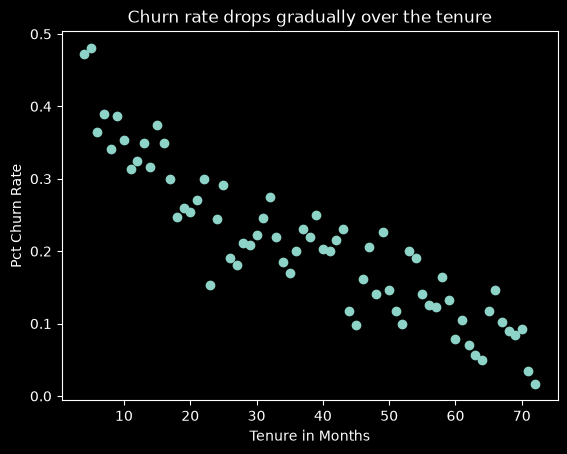

In [7]:
# churn rate by tenure > 3
query = """
SELECT
  se.tenure_in_months,
  COUNTIF(st.churn_label) AS churners,
  COUNT(*) AS customers,
  ROUND(COUNTIF(st.churn_label) * 1.0 / COUNT(*), 3) AS pct_churn
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  se.tenure_in_months
"""

df = run_query(query)
plt.scatter(df["tenure_in_months"], df["pct_churn"])
plt.xlabel("Tenure in Months")
plt.ylabel("Pct Churn Rate")
plt.title("Churn rate drops gradually over the tenure");

Tenure has a negative correlation with churn.

In [8]:
# - What share of *all churners* sits in the first 12 months?

query = """
SELECT
  CASE
    WHEN se.tenure_in_months <= 12 THEN '4-12'
    WHEN se.tenure_in_months <= 24 THEN '13-24'
    WHEN se.tenure_in_months <= 48 THEN '25-48'
    ELSE '48+'
  END AS tenure_band,
  COUNT(*) AS churners,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER (), 3) AS pct_of_churn
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
  AND st.customer_status = 'churned'
GROUP BY
  tenure_band
"""

run_query(query)

,tenure_band,churners,pct_of_churn
0,4-12,440,0.346
1,48+,213,0.167
2,13-24,294,0.231
3,25-48,325,0.256


## Age

In [9]:
# which age group churn more?
query = """
SELECT
  IF(age < 65, FALSE, TRUE) AS is_senior,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_churn
FROM
  `dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  is_senior
"""

df = run_query(query)
df.rename(index={0: False, 1: True})

,is_senior,customers,churners,pct_churn
False,False,5004,920,0.184
True,True,988,352,0.356


In [10]:
compare(
    df.loc[(df["is_senior"] == True), "churners"].item(),
    df.loc[(df["is_senior"] == True), "customers"].item(),
    df.loc[(df["is_senior"] == False), "churners"].item(),
    df.loc[(df["is_senior"] == False), "customers"].item(),
    "senior",
    "non-senior",
)

senior:   35.6%  (32.7, 38.7)   n=988
non-senior:   18.4%  (17.3, 19.5)   n=5004
diff:    17.2pp (14.1, 20.5)
ratio:   1.94x (1.75, 2.15)


Seniors churn at `35.6%` against `18.4%` — `17.2` ((`95% CI 14.1 to 20.5`))points higher, or `1.93×` the rate (`95% CI 1.74 to 2.14`).

In [11]:
# Age composition of churners

query = """
SELECT
  IF(d.age < 65, FALSE, TRUE) AS is_senior,
  COUNT(*) AS churners,
  SUM(COUNT(*)) OVER () AS total_churners,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER (), 3) AS pct_of_churn
FROM
  `dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  st.customer_status = 'churned'
  AND se.tenure_in_months > 3
GROUP BY
  is_senior
"""

run_query(query)

,is_senior,churners,total_churners,pct_of_churn
0,False,920,1272,0.723
1,True,352,1272,0.277


## 3. Contract, billing and payment

- Churn rate by `contract` ('month-to-month', 'one year', 'two year'). This is usually
  the single strongest lever - how large is the gap here?
- Churn rate by `payment_method` and by `paperless_billing`. Are these real effects, or
  just proxies for contract type?
- What share of the customer base is month-to-month, and what share of total
  `monthly_charge` does that represent? (Sizes the exposure.)


In [24]:
query = """
SELECT
    se.contract,
    COUNT(*) AS customers,
    COUNTIF(st.churn_label) AS churners,
    ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_churn
FROM
    `focus-appliance-507309-h8.dbt_dev.stg_telco__services` se
    JOIN `focus-appliance-507309-h8.dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
    se.tenure_in_months > 3
GROUP BY
    se.contract
"""

df = run_query(query)
df

,contract,customers,churners,pct_churn
0,one year,1524,164,0.108
1,two year,1861,48,0.026
2,month-to-month,2607,1060,0.407


In [25]:
compare_groups(
    {
        "month-to-month": (
            df.loc[(df["contract"] == "month-to-month"), "churners"].item(),
            df.loc[(df["contract"] == "month-to-month"), "customers"].item(),
        ),
        "one year": (
            df.loc[(df["contract"] == "one year"), "churners"].item(),
            df.loc[(df["contract"] == "one year"), "customers"].item(),
        ),
        "two year": (
            df.loc[(df["contract"] == "two year"), "churners"].item(),
            df.loc[(df["contract"] == "two year"), "customers"].item(),
        ),
    },
    reference="month-to-month",
)


reference: month-to-month   omnibus chi2=1075.6, dof=2, p=2.77e-234



,group,n,churners,rate,ci_lo,ci_hi,thin,diff,diff_lo,diff_hi,ratio,excess,p,p_adj
2,two year,1861,48,2.6,2.0,3.4,False,-38.1,-40.1,-36.0,0.06,-709.0,1.224719e-185,2.449439e-185
1,one year,1524,164,10.8,9.3,12.4,False,-29.9,-32.3,-27.4,0.26,-456.0,1.133770e-91,1.133770e-91
0,month-to-month,2607,1060,40.7,38.8,42.6,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


customer on month-to-month contracts have a churn rate of `40.7%` against `9.3%` for one year (`29.9pp diff, 3.8x more `) and `2.6%` for a two year contract (`38.1pp diff, 16.6x more`).

## Internet type

In [19]:
# What is the churn rate within each internet type

query = """
SELECT
  se.internet_type,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_churn
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  se.internet_type
"""

df = run_query(query)
df

,internet_type,customers,churners,pct_churn
0,none,1274,43,0.034
1,dsl,1411,181,0.128
2,cable,694,133,0.192
3,fiber optic,2613,915,0.350


In [21]:
compare_groups(
    {
        "dsl": (
            df.loc[(df["internet_type"] == "dsl"), "churners"].item(),
            df.loc[(df["internet_type"] == "dsl"), "customers"].item(),
        ),
        "cable": (
            df.loc[(df["internet_type"] == "cable"), "churners"].item(),
            df.loc[(df["internet_type"] == "cable"), "customers"].item(),
        ),
        "fiber optic": (
            df.loc[(df["internet_type"] == "fiber optic"), "churners"].item(),
            df.loc[(df["internet_type"] == "fiber optic"), "customers"].item(),
        ),
    },
    reference="dsl",
)


reference: dsl   omnibus chi2=254.2, dof=2, p=6.29e-56



,group,n,churners,rate,ci_lo,ci_hi,thin,diff,diff_lo,diff_hi,ratio,excess,p,p_adj
0,dsl,1411,181,12.8,11.2,14.7,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cable,694,133,19.2,16.4,22.3,False,6.3,3.0,9.8,1.49,44.0,1.249359e-04,1.249359e-04
2,fiber optic,2613,915,35.0,33.2,36.9,False,22.2,19.6,24.7,2.73,580.0,1.956732e-51,3.913464e-51


Fiber Optic customers have a `35%` churn rate against a `12.8%` churn rate for DSL customers, a significant `22.2` percentage point difference.  while cable customers have a `19.2%` churn rate, which is `7.3` percentage points lower than fiber optic customers, but still `6.4` percentage points higher than DSL customers. This suggests that internet type may be a significant factor in churn, with fiber optic customers being the most likely to churn, followed by cable customers, and DSL customers being the least likely to churn. Further analysis is needed to determine if this effect persists when controlling for other variables such as contract type and monthly charge.

## Credit Card Effect

In [29]:
query = """
select
  se.payment_method,
  count(*) as customers,
  countif(st.churn_label) as churners,
  round(countif(st.churn_label) / count(*), 3) as pct_churn
from `focus-appliance-507309-h8.dbt_dev.stg_telco__services` se
join `focus-appliance-507309-h8.dbt_dev.stg_telco__status` st
using(customer_id)
where se.tenure_in_months > 3
group by se.payment_method
"""

df = run_query(query)
df


,payment_method,customers,churners,pct_churn
0,credit card,2391,271,0.113
1,mailed check,261,60,0.230
2,bank withdrawal,3340,941,0.282


In [30]:
query = """
SELECT
  IF(
    se.payment_method = 'credit card',
    'card',
    'non-card'
  ) AS pay,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_churn
FROM
  `focus-appliance-507309-h8.dbt_dev.stg_telco__services` se
  JOIN `focus-appliance-507309-h8.dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  pay
"""

df = run_query(query)
df

,pay,customers,churners,pct_churn
0,card,2391,271,0.113
1,non-card,3601,1001,0.278


In [31]:
compare(
    df.loc[(df["pay"] == "non-card"), "churners"].item(),
    df.loc[(df["pay"] == "non-card"), "customers"].item(),
    df.loc[(df["pay"] == "card"), "churners"].item(),
    df.loc[(df["pay"] == "card"), "customers"].item(),
    "non-card",
    "card",
)


non-card:   27.8%  (26.4, 29.3)   n=3601
card:   11.3%  (10.1, 12.7)   n=2391
diff:    16.5pp (14.5, 18.4)
ratio:   2.45x (2.17, 2.78)


## Remaining demographics

## 2. Demographics

In [12]:
query = """
SELECT
  d.married,
  count(*) as customers,
  countif(st.churn_label) as churners,
  round(countif(st.churn_label) / count(*), 3) as pct_of_churn
FROM `dbt_dev.stg_telco__demographics` d
join `dbt_dev.stg_telco__status` st
using(customer_id)
join `dbt_dev.stg_telco__services` se
using(customer_id)
where se.tenure_in_months > 3
group by married
"""

df = run_query(query)
df

,married,customers,churners,pct_of_churn
0,True,3209,560,0.175
1,False,2783,712,0.256


In [13]:
compare(
    df.loc[(df["married"] == False), "churners"].item(),
    df.loc[(df["married"] == False), "customers"].item(),
    df.loc[(df["married"] == True), "churners"].item(),
    df.loc[(df["married"] == True), "customers"].item(),
    "not married",
    "married",
)

not married:   25.6%  (24.0, 27.2)   n=2783
married:   17.5%  (16.2, 18.8)   n=3209
diff:    8.1pp (6.0, 10.2)
ratio:   1.47x (1.33, 1.62)


`not married` customers churn at `25.6%` against `17.5%` - `8.1` (`95% CI 6.0 to 10.2`) points higher, or `1.47×` the rate (`95% CI 1.33 to 1.62`).

In [14]:
query = """
SELECT
  d.number_of_dependents,
  COUNT(*) AS customer,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_of_churn
FROM
  `dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  d.number_of_dependents
"""

run_query(query)

,number_of_dependents,customer,churners,pct_of_churn
0,0,4484,1205,0.269
1,1,517,29,0.056
2,2,491,18,0.037
3,3,478,17,0.036
4,4,8,1,0.125
5,5,8,1,0.125
6,6,3,1,0.333
7,7,1,0,0.000
8,8,1,0,0.000
9,9,1,0,0.000


0 dependents churned at a rate of `26.9%`, which is not significantly higher than the overall churn rate of `26.5%`. however, churn rates among customer with dependents seem to be significantly lower, ranging from `5.6%` to `3.6%`. (Dependents count from 4 above is too small to be significant.) This suggests that having dependents may be a factor in churn, but further analysis is needed to determine if this effect persists when controlling for other variables such as contract type and monthly charge.

In [15]:
query = """
SELECT
  IF(
    d.number_of_dependents = 0,
    'zero-dependents',
    '1+dependents'
  ) AS dependents,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_of_churn
FROM
  `focus-appliance-507309-h8.dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3

GROUP BY
  dependents
"""

df = run_query(query)

In [16]:
compare(
    df.loc[(df["dependents"] == "zero-dependents"), "churners"].item(),
    df.loc[(df["dependents"] == "zero-dependents"), "customers"].item(),
    df.loc[(df["dependents"] == "1+dependents"), "churners"].item(),
    df.loc[(df["dependents"] == "1+dependents"), "customers"].item(),
    "zero-dependents",
    "1+dependents",
)

zero-dependents:   26.9%  (25.6, 28.2)   n=4484
1+dependents:   4.4%  (3.5, 5.6)   n=1508
diff:    22.4pp (20.7, 24.0)
ratio:   6.05x (4.76, 7.68)


Zero Dependents churn at `26.9%` against `4.3%` - `22.6` (`95% CI 20.8 to 24.2`) points higher, or `6.24x` the rate (`95% CI 4.89 to 7.97`).

In [17]:
query = """
SELECT
  d.gender,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_of_churn
FROM
  `focus-appliance-507309-h8.dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  d.gender
"""

df = run_query(query)

In [18]:
compare(
    df.loc[(df["gender"] == "male"), "churners"].item(),
    df.loc[(df["gender"] == "male"), "customers"].item(),
    df.loc[(df["gender"] == "female"), "churners"].item(),
    df.loc[(df["gender"] == "female"), "customers"].item(),
    "male",
    "female",
)

male:   21.1%  (19.7, 22.6)   n=3019
female:   21.4%  (19.9, 22.9)   n=2973
diff:    -0.3pp (-2.3, 1.8)
ratio:   0.99x (0.90, 1.09)


both genders have a churn rate of around `21.3%`. and a non signicicant difference (`-0.3pp  ± 2pp`) between them. This suggests that gender may not be a significant factor in churn, but further analysis is needed to confirm this finding and determine if it persists when controlling for other variables such as contract type and monthly charge.

## Remaining service and billing

## 5. Service mix
- Do the streaming flags and `unlimited_data` matter once internet type is held constant?
- Phone-only and internet-only customers: how do they compare to bundled ones?


In [22]:
# whats is the churn rate of individuals with add-ons

query = """
SELECT
  addon_count,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners,
  ROUND(COUNTIF(churn_label) / COUNT(churn_label), 3) AS pct_of_churn
FROM
  (
    SELECT
      *,
      CAST(online_security AS INT64) + CAST(online_backup AS INT64) + CAST(device_protection_plan AS INT64) + CAST(premium_tech_support AS INT64) AS addon_count
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.internet_service = TRUE
      AND se.tenure_in_months > 3
  )
GROUP BY
  addon_count
ORDER BY
  addon_count
"""

df = run_query(query)
df


,addon_count,customers,churners,pct_of_churn
0,0,773,361,0.467
1,1,1241,441,0.355
2,2,1303,289,0.222
3,3,931,113,0.121
4,4,470,25,0.053


`add-on` services (online security, online backup, device protection plan, premium tech support) are associated with lower churn rates. Customers with more add-ons tend to be stickier, suggesting that bundling services may improve retention.

In [23]:
query = """
SELECT
  streaming_count,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners,
  ROUND(COUNTIF(churn_label) / COUNT(churn_label), 3) AS pct_of_churn
FROM
  (
    SELECT
      *,
      CAST(streaming_movies AS INT64) + CAST(streaming_tv AS INT64) + CAST(streaming_music AS INT64) AS streaming_count
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      internet_service = TRUE
      AND se.tenure_in_months > 3
  )
GROUP BY
  streaming_count
ORDER BY
  streaming_count
"""

run_query(query)

,streaming_count,customers,churners,pct_of_churn
0,0,1428,334,0.234
1,1,811,241,0.297
2,2,886,258,0.291
3,3,1593,396,0.249


customers who don't use any streaming service have a churn rate of `23.4%`, while those who use one or two have a churn rate of around `29.7%`. With customers who use 3 services having a churn rate of `24.9%`.

In [42]:
query = """
SELECT
  se.paperless_billing,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_churn
FROM
  `focus-appliance-507309-h8.dbt_dev.stg_telco__services` se
  JOIN `focus-appliance-507309-h8.dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  se.paperless_billing
"""

df = run_query(query)
df


,paperless_billing,customers,churners,pct_churn
0,False,2430,284,0.117
1,True,3562,988,0.277


# Pairwise interactions (first pass)

The original hand-rolled crosses: contract against age, payment against
contract, payment against age. `Interaction tests` below re-runs this kind of
question through one common set of functions.

## Contract x Age group

In [26]:
# Contract Share across Age group
query = """
WITH
  base AS (
    SELECT
      IF(d.age < 65, 'non-senior', 'senior') AS is_senior,
      se.contract,
      st.churn_label
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
      JOIN `dbt_dev.stg_telco__demographics` d USING(customer_id)
    WHERE
      se.tenure_in_months > 3
  )
SELECT
  contract,
  COUNT(*) AS customers,
  round(countif(is_senior = 'senior') / count(*), 3) as senior,
  round(countif(is_senior = 'non-senior') / count(*), 3) as not_senior,
FROM
  base
GROUP BY
  contract
"""

df = run_query(query)
df


,contract,customers,senior,not_senior
0,one year,1524,0.171,0.829
1,two year,1861,0.170,0.830
2,month-to-month,2607,0.157,0.843


In [27]:
# Contract Rate across Age group
query = """
WITH
  base AS (
    SELECT
      IF(d.age < 65, 'non-senior', 'senior') AS is_senior,
      se.contract,
      st.churn_label
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
      JOIN `dbt_dev.stg_telco__demographics` d USING(customer_id)
    WHERE
      se.tenure_in_months > 3
  )
SELECT
  is_senior,
  contract,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners,
  ROUND(SAFE_DIVIDE(COUNTIF(churn_label), COUNT(*)), 3) AS churn_rate
FROM
  base
GROUP BY
  is_senior,
  contract
ORDER BY
  is_senior,
  contract
"""

df = run_query(query)
df


,is_senior,contract,customers,churners,churn_rate
0,non-senior,month-to-month,2197,743,0.338
1,non-senior,one year,1263,135,0.107
2,non-senior,two year,1544,42,0.027
3,senior,month-to-month,410,317,0.773
4,senior,one year,261,29,0.111
5,senior,two year,317,6,0.019


In [28]:
# Total gap percentage points; Composition and Rate PP
kitagawa(
    df,
    group="contract",
    strata="is_senior",
    n="customers",
    k="churners",
    a="month-to-month",
    b="two year",
)


{'rate_a': 40.7,
 'rate_b': 2.6,
 'gap_pp': 38.1,
 'rate_effect_pp': 38.4,
 'composition_pp': -0.3,
 'composition_share': -0.01}

no detectable senior effect on committed contracts,

### Payment Method x Contract Type

In [32]:
# Payment Method Share across Contract
query = """
WITH
  base AS (
    SELECT
      CASE
        WHEN se.payment_method = 'credit card' THEN 'card'
        ELSE 'non-card'
      END AS pay,
      se.contract,
      st.churn_label
    FROM
      `focus-appliance-507309-h8.dbt_dev.stg_telco__services` se
      JOIN `focus-appliance-507309-h8.dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.tenure_in_months > 3
  )
SELECT
  pay,
  COUNT(*) AS customers,
  ROUND(COUNTIF(contract = 'two year') / COUNT(*), 3) AS pct_twoyear,
  ROUND(COUNTIF(contract = 'one year') / COUNT(*), 3) AS pct_oneyear,
  ROUND(
    COUNTIF(contract = 'month-to-month') / COUNT(*),
    3
  ) AS pct_m2m
FROM
  base
GROUP BY
  pay
"""

df = run_query(query)
df


,pay,customers,pct_twoyear,pct_oneyear,pct_m2m
0,card,2391,0.391,0.274,0.334
1,non-card,3601,0.257,0.241,0.502


In [33]:
# Payment Method Rate across Contract
query = """
WITH
  base AS (
    SELECT
      CASE
        WHEN se.payment_method = 'credit card' THEN 'card'
        ELSE 'non-card'
      END AS pay,
      se.contract,
      st.churn_label
    FROM
      `focus-appliance-507309-h8.dbt_dev.stg_telco__services` se
      JOIN `focus-appliance-507309-h8.dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.tenure_in_months > 3
  )
SELECT
  contract,
  pay,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners,
  ROUND(SAFE_DIVIDE(COUNTIF(churn_label), COUNT(*)), 3) AS churn_rate
FROM
  base
GROUP BY
  contract,
  pay
ORDER BY
  contract,
  pay
"""

df = run_query(query)
df

,contract,pay,customers,churners,churn_rate
0,month-to-month,card,799,204,0.255
1,month-to-month,non-card,1808,856,0.473
2,one year,card,656,51,0.078
3,one year,non-card,868,113,0.130
4,two year,card,936,16,0.017
5,two year,non-card,925,32,0.035


In [34]:
# Total gap percentage points; Composition and Rate PP
kitagawa(
    df,
    group="pay",
    strata="contract",
    n="customers",
    k="churners",
    a="non-card",
    b="card",
)


{'rate_a': 27.8,
 'rate_b': 11.3,
 'gap_pp': 16.5,
 'rate_effect_pp': 11.0,
 'composition_pp': 5.4,
 'composition_share': 0.33}

In [35]:
raw = """
WITH
  base AS (
    SELECT
      CASE
        WHEN se.payment_method = 'credit card' THEN 'card'
        ELSE 'non-card'
      END AS pay,
      se.contract,
      st.churn_label
    FROM
      `focus-appliance-507309-h8.dbt_dev.stg_telco__services` se
      JOIN `focus-appliance-507309-h8.dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.tenure_in_months > 3
  )
SELECT
  contract,
  pay,
  churn_label as churned
FROM
  base
ORDER BY
  contract,
  pay

"""

raw_df = run_query(raw)

In [36]:
from statsmodels.stats.contingency_tables import StratifiedTable

raw_df["churned"] = np.where(raw_df.churned, "1_churned", "2_stayed")
tb = StratifiedTable.from_data("pay", "churned", "contract", raw_df)


In [37]:
sr = StratifiedTable(tb.table)
sr.summary()


,Estimate,LCB,UCB
Pooled odds,0.420,0.359,0.491
Pooled log odds,-0.868,-1.025,-0.711
Pooled risk ratio,0.546,,
,,,
,Statistic,P-value,
Test of OR=1,121.777,0.000,
Test constant OR,4.035,0.133,
,,,
Number of tables,3,,
Min n,1524,,


customer who do not pay with credit cards have a churn of `27.8%` as against `11.3%` (`16.5pp diff, 2.4x`). On the same contract type, they are `1.83×` as likely to churn. About a third of the raw gap reflects non-card customers being more concentrated on month-to-month contracts.

Credit card payment is associated with roughly 45% lower churn, and the relationship holds at similar strength across all three contract types. In absolute terms the effect is concentrated where churn is highest: 21.8 points lower among month-to-month customers, against under 2 points among two-year customers. Adjusting for contract type reduces the apparent advantage from 3.0× to 2.4×, since card customers already skew toward longer contracts.


### Payment Method x Age group

In [38]:
# Payment Method Share across Age group
query = """
# Payment Method Share across Contract
WITH
  base AS (
    SELECT
      CASE
        WHEN se.payment_method = 'credit card' THEN 'card'
        ELSE 'non-card'
      END AS pay,
      IF(d.age < 65, FALSE, TRUE) AS is_senior,
      st.churn_label
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
      JOIN `dbt_dev.stg_telco__demographics` d USING(customer_id)
    WHERE
      se.tenure_in_months > 3
  )

  select
  pay,
  count(*) as customers,
  round(countif(is_senior = True) / count(*), 3) as senior,
  round(countif(is_senior = False) / count(*), 3) as not_senior,
from base
group by pay

"""

df = run_query(query)
df


,pay,customers,senior,not_senior
0,card,2391,0.108,0.892
1,non-card,3601,0.203,0.797


In [39]:
# Payment Method Rate across Contract
query = """
WITH
  base AS (
    SELECT
      CASE
        WHEN se.payment_method = 'credit card' THEN 'card'
        ELSE 'non-card'
      END AS pay,
      IF(d.age < 65, 'non-senior', 'senior') AS is_senior,
      st.churn_label
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
      JOIN `dbt_dev.stg_telco__demographics` d USING(customer_id)
    WHERE
      se.tenure_in_months > 3
  )
SELECT
  is_senior,
  pay,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners,
  ROUND(SAFE_DIVIDE(COUNTIF(churn_label), COUNT(*)), 3) AS churn_rate
FROM
  base
GROUP BY
  is_senior,
  pay
ORDER BY
  is_senior,
  pay
"""

df = run_query(query)
df


,is_senior,pay,customers,churners,churn_rate
0,non-senior,card,2133,196,0.092
1,non-senior,non-card,2871,724,0.252
2,senior,card,258,75,0.291
3,senior,non-card,730,277,0.379


In [40]:
# Total gap percentage points; Composition and Rate PP
kitagawa(
    df,
    group="pay",
    strata="is_senior",
    n="customers",
    k="churners",
    a="non-card",
    b="card",
)

{'rate_a': 27.8,
 'rate_b': 11.3,
 'gap_pp': 16.5,
 'rate_effect_pp': 14.9,
 'composition_pp': 1.5,
 'composition_share': 0.09}

In [41]:
tables = [
    np.array([[196, 2133 - 196], [724, 2871 - 724]]),  # non-senior
    np.array([[75, 258 - 75], [277, 730 - 277]]),  # senior
]
StratifiedTable(tables).summary()


,Estimate,LCB,UCB
Pooled odds,0.357,0.308,0.414
Pooled log odds,-1.029,-1.176,-0.882
Pooled risk ratio,0.441,,
,,,
,Statistic,P-value,
Test of OR=1,199.629,0.000,
Test constant OR,20.484,0.000,
,,,
Number of tables,2,,
Min n,988,,


# Interaction tests

Each cut below is read the same way: the grid gives the churn rate and n for every
cell against the base rate, `stratified` asks whether the headline gap survives
holding the second variable constant (Mantel-Haenszel), whether that effect is the
same in every stratum (homogeneity), and how much of the crude gap is only a
difference in mix (Kitagawa). All cuts keep the `tenure > 3` onboarding filter.

Three steps are added on top of the grids and the stratified comparison:

- **direct standardization** - re-weights every group to the pooled mix of the
  second variable, so the standardized rates are what each group would post if
  they all carried the same mix. It answers the same question as the Kitagawa
  line, on the rate scale and with a CI.
- **logistic regression with an interaction term** - `churn ~ group + strata`
  (one effect everywhere, the model form of Mantel-Haenszel) against
  `churn ~ group * strata` (the effect free to vary by stratum).
- **likelihood-ratio test** comparing the two, $LR = 2(LL_{interaction} -
  LL_{additive})$, referred to $\chi^2$ on the added degrees of freedom. A
  small p means the interaction earns its parameters; it is the formal version
  of the homogeneity test, and of whether the lines in the interaction plot run
  parallel on the log-odds scale.

## Age x Tenure

churn rate: age_group x tenure_band   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

tenure_band    non-senior       senior   |         all 
-------------------------------------------------------
4-12           35.8 (969)   56.0 (166)   | 38.8 (1,135) 
13-24          24.6 (856)   49.4 (168)   | 28.7 (1,024) 
25-48        15.9 (1,313)   41.3 (281)   | 20.4 (1,594) 
49+           8.2 (1,866)   16.1 (373)   | 9.5 (2,239) 
-------------------------------------------------------
all          18.4 (5,004)   35.6 (988)   | 21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across tenure_band); last line = share of all customers

tenure_band    non-senior       senior   |         all 
-------------------------------------------------------
4-12                 19.4         16.8   |       18.9  
13-24                17.1         17.0   |       17.1  
25-48                26.2         28.4   |       26.6  
49+                 

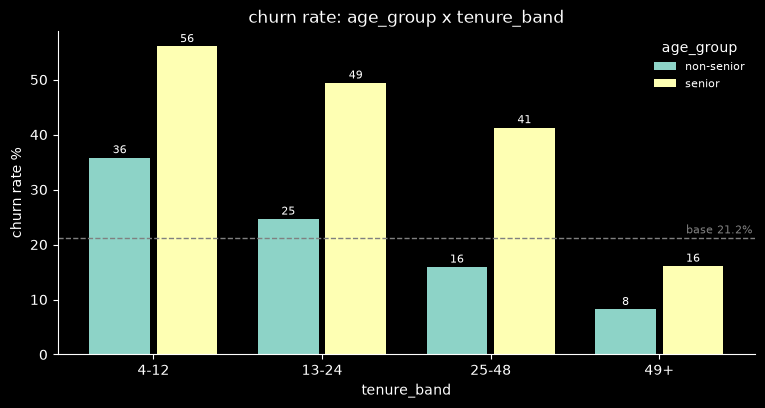

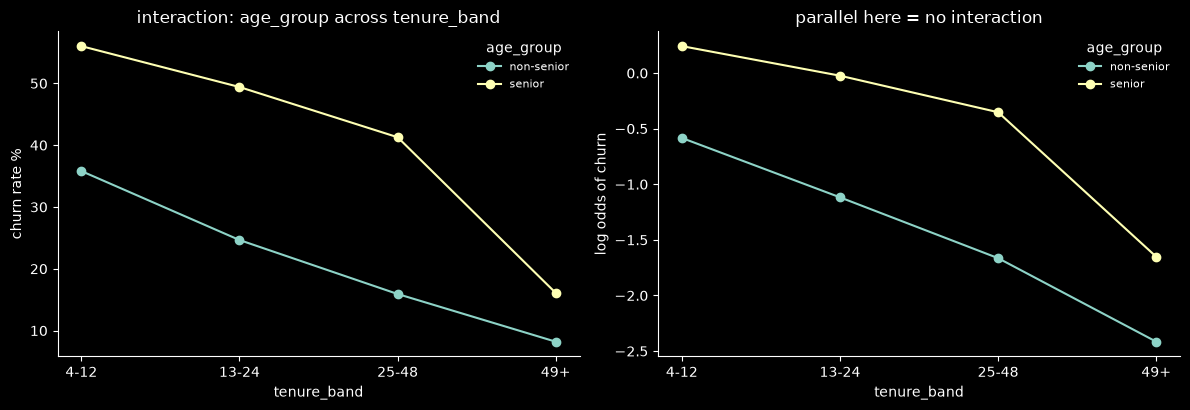

In [43]:
# Does the senior penalty hold at every stage of the lifecycle, or is it just that
# seniors sit in younger tenure bands?
query = """
SELECT
  IF(d.age < 65, 'non-senior', 'senior') AS age_group,
  CASE
    WHEN se.tenure_in_months <= 12 THEN '4-12'
    WHEN se.tenure_in_months <= 24 THEN '13-24'
    WHEN se.tenure_in_months <= 48 THEN '25-48'
    ELSE '49+'
  END AS tenure_band,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__demographics` d USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  age_group,
  tenure_band
"""

df = run_query(query)
df["tenure_band"] = band(df["tenure_band"], ["4-12", "13-24", "25-48", "49+"])

rate_grid(df, rows="tenure_band", cols="age_group")
stratified(df, group="age_group", strata="tenure_band", a="senior", b="non-senior")
standardize(df, group="age_group", strata="tenure_band")
model_compare(df, group="age_group", strata="tenure_band")

plot_grid(df, rows="tenure_band", cols="age_group");
plot_interaction(df, rows="tenure_band", cols="age_group");

Seniors churn at 35.6% vs 18.4% (17.2pp, 95% CI 14.0–20.4; RR 1.93). Tenure does not confound; composition −0.5pp.

About one in three senior customers leaves, against fewer than one in five of everyone else. That's roughly 170 more departures a year than if seniors behaved like other customers. It isn't that seniors are newer customers — they've been with us slightly longer on average.

## Age X Contract

churn rate: age_group x contract   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

contract          non-senior       senior   |         all 
----------------------------------------------------------
month-to-month  33.8 (2,197)   77.3 (410)   | 40.7 (2,607) 
one year        10.7 (1,263)   11.1 (261)   | 10.8 (1,524) 
two year         2.7 (1,544)    1.9 (317)   | 2.6 (1,861) 
----------------------------------------------------------
all             18.4 (5,004)   35.6 (988)   | 21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across contract); last line = share of all customers

contract          non-senior       senior   |         all 
----------------------------------------------------------
month-to-month          43.9         41.5   |       43.5  
one year                25.2         26.4   |       25.4  
two year                30.9         32.1   |       31.1  
-----------------------------------------------

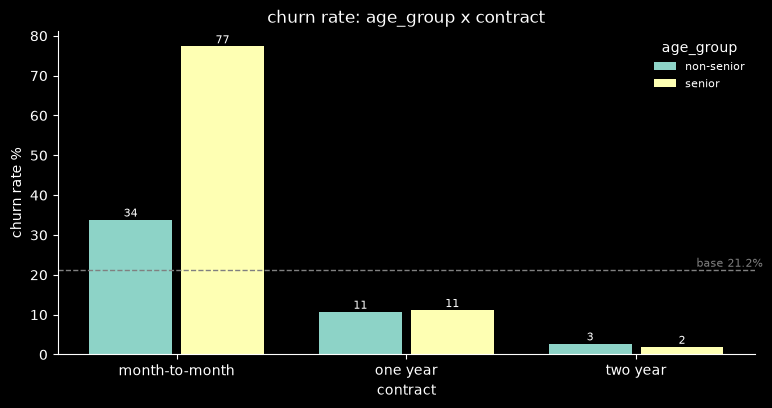

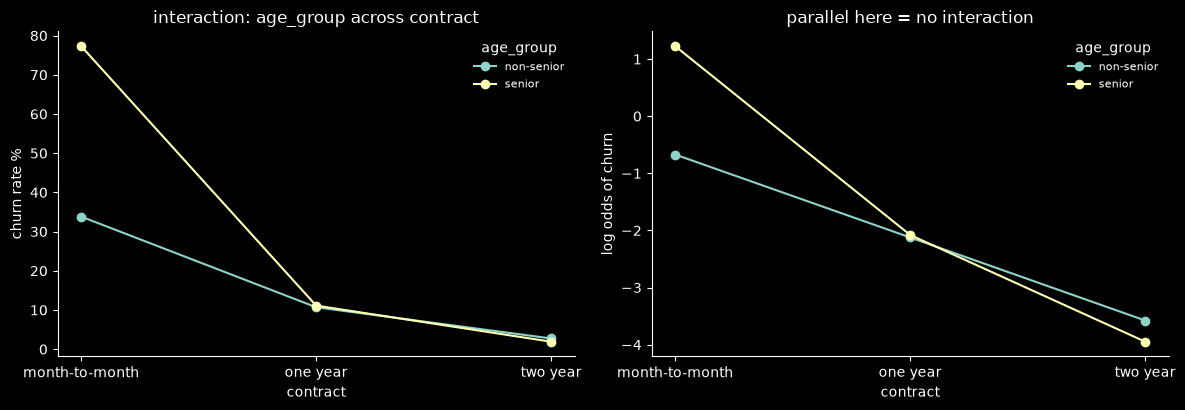

In [73]:
# Does the senior penalty hold at every contract?, or is it just that seniors sit in more volitile contacts group ?
query = """
SELECT
  IF(d.age < 65, 'non-senior', 'senior') AS age_group,
  se.contract,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__demographics` d USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  age_group,
  contract
"""

df = run_query(query)

rate_grid(df, rows="contract", cols="age_group")
stratified(df, group="age_group", strata="contract", a="senior", b="non-senior")
standardize(df, group="age_group", strata="contract")
model_compare(df, group="age_group", strata="contract")

plot_grid(df, rows="contract", cols="age_group");
plot_interaction(df, rows="contract", cols="age_group");

## Age X Internet Type

churn rate: age_group x internet_type   |   base 27.2%   |   4,024 customers, 1,096 churners

churn rate: rate% (n)   * = n<100

internet_type    non-senior       senior   |         all 
---------------------------------------------------------
dsl            12.0 (1,256)   19.4 (155)   | 12.8 (1,411) 
fiber optic    33.0 (1,908)   40.6 (705)   | 35.0 (2,613) 
---------------------------------------------------------
all            24.7 (3,164)   36.7 (860)   | 27.2 (4,024) 

customer mix %: each column sums to 100 (how the group spreads across internet_type); last line = share of all customers

internet_type    non-senior       senior   |         all 
---------------------------------------------------------
dsl                    39.7         18.0   |       35.1  
fiber optic            60.3         82.0   |       64.9  
---------------------------------------------------------
all                    78.6         21.4   |      100.0  

share of all churners %: the grid sums to 100 (w

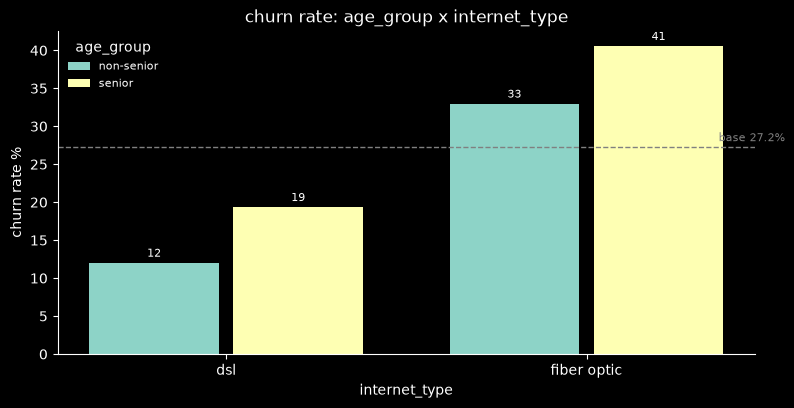

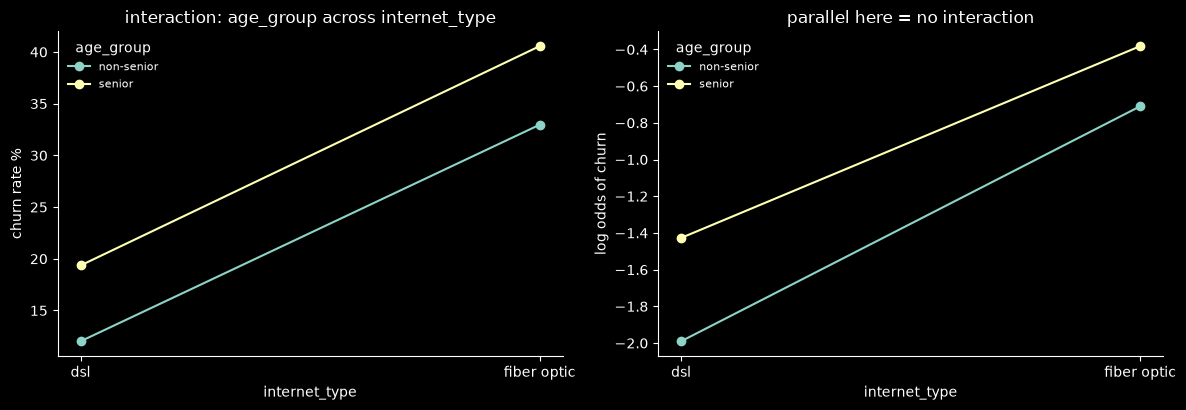

In [75]:
# Does the senior penalty hold at every Internet Type, or is it just that seniors sit in more volitile internet type (fiber)?
query = """
SELECT
  IF(d.age < 65, 'non-senior', 'senior') AS age_group,
  se.internet_type,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__demographics` d USING (customer_id)
WHERE
  se.tenure_in_months > 3
  AND se.internet_type IN ('dsl','fiber optic')
GROUP BY
  age_group,
  internet_type
"""

df = run_query(query)

rate_grid(df, rows="internet_type", cols="age_group")
stratified(df, group="age_group", strata="internet_type", a="senior", b="non-senior")
standardize(df, group="age_group", strata="internet_type")
model_compare(df, group="age_group", strata="internet_type")

plot_grid(df, rows="internet_type", cols="age_group")
plot_interaction(df, rows="internet_type", cols="age_group");


## Internet type x Add-ons

churn rate: addon_band x internet_type   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

internet_type             0            1           2+   |         all 
----------------------------------------------------------------------
cable             42.5 (80)*  29.3 (157)   11.6 (457)   |  19.2 (694) 
dsl              25.7 (152)   23.7 (325)    7.0 (934)   | 12.8 (1,411) 
fiber optic      53.2 (541)   41.9 (759) 23.5 (1,313)   | 35.0 (2,613) 
----------------------------------------------------------------------
all              46.7 (773) 35.5 (1,241) 15.8 (2,704)   | 26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across internet_type); last line = share of all customers

internet_type             0            1           2+   |         all 
----------------------------------------------------------------------
cable                  10.3         12.7         16.9   |       14.7  
dsl                    19.7       

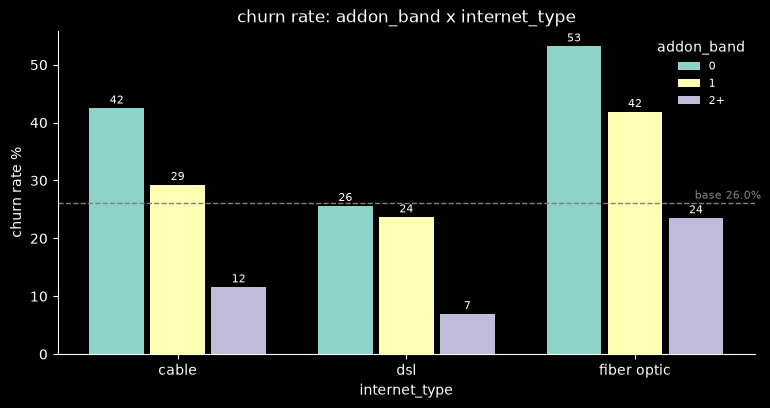

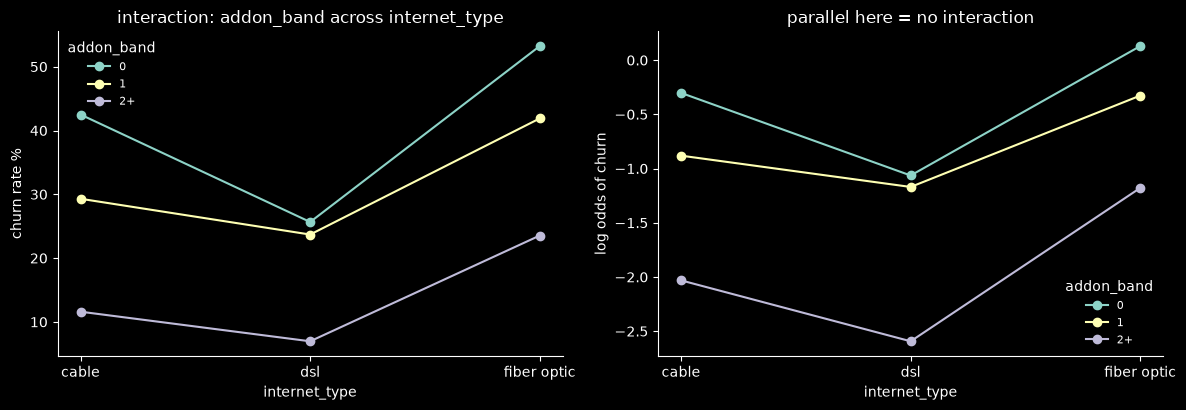

In [44]:
# Add-ons look protective overall - but fiber sells fewer of them. Is the add-on
# effect real inside each internet type, or an artefact of who buys which product?
# Add-ons: online security, online backup, device protection, premium tech support.
query = """
SELECT
  internet_type,
  CASE
    WHEN addons = 0 THEN '0'
    WHEN addons = 1 THEN '1'
    ELSE '2+'
  END AS addon_band,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners
FROM
  (
    SELECT
      se.internet_type,
      st.churn_label,
      CAST(se.online_security AS INT64) + CAST(se.online_backup AS INT64) + CAST(se.device_protection_plan AS INT64) + CAST(se.premium_tech_support AS INT64) AS addons
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.tenure_in_months > 3
      AND se.internet_service = TRUE
  )
GROUP BY
  internet_type,
  addon_band
"""

df = run_query(query)
df["addon_band"] = band(df["addon_band"], ["0", "1", "2+"])

rate_grid(df, rows="internet_type", cols="addon_band")
stratified(df, group="addon_band", strata="internet_type", a="0", b="2+")
standardize(df, group="addon_band", strata="internet_type")
model_compare(df, group="addon_band", strata="internet_type")

plot_grid(df, rows="internet_type", cols="addon_band");
plot_interaction(df, rows="internet_type", cols="addon_band");

Among the `4718` customers who are not in the **onboarding** phase and suscribe to internet service. Customers with 2+ addons have substantially lower churn (`≈60%`) than customers with 0 addons. This relationship is broadly consistent across internet types, with no strong evidence of interaction (homogeneity \(p=0.277\); LR interaction \(p=0.052\)). Internet-type composition differs across addon groups and explains roughly 13–14% of the crude churn gap, so some confounding is present, but most of the difference remains after adjustment. Thus, one common addon effect is a reasonable summary, with the important caveat that the interaction test is borderline.

## Internet type x Contract

churn rate: internet_type x contract   |   base 27.2%   |   4,024 customers, 1,096 churners

churn rate: rate% (n)   * = n<100

contract                 dsl  fiber optic   |         all 
----------------------------------------------------------
month-to-month    24.5 (555) 53.3 (1,475)   | 45.4 (2,030) 
one year           8.9 (403)   16.8 (583)   |  13.6 (986) 
two year           2.0 (453)    5.6 (555)   | 4.0 (1,008) 
----------------------------------------------------------
all             12.8 (1,411) 35.0 (2,613)   | 27.2 (4,024) 

customer mix %: each column sums to 100 (how the group spreads across contract); last line = share of all customers

contract                 dsl  fiber optic   |         all 
----------------------------------------------------------
month-to-month          39.3         56.4   |       50.4  
one year                28.6         22.3   |       24.5  
two year                32.1         21.2   |       25.0  
--------------------------------------------

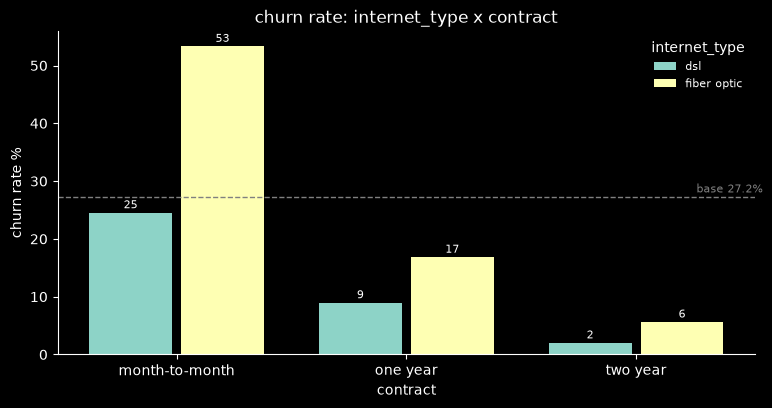

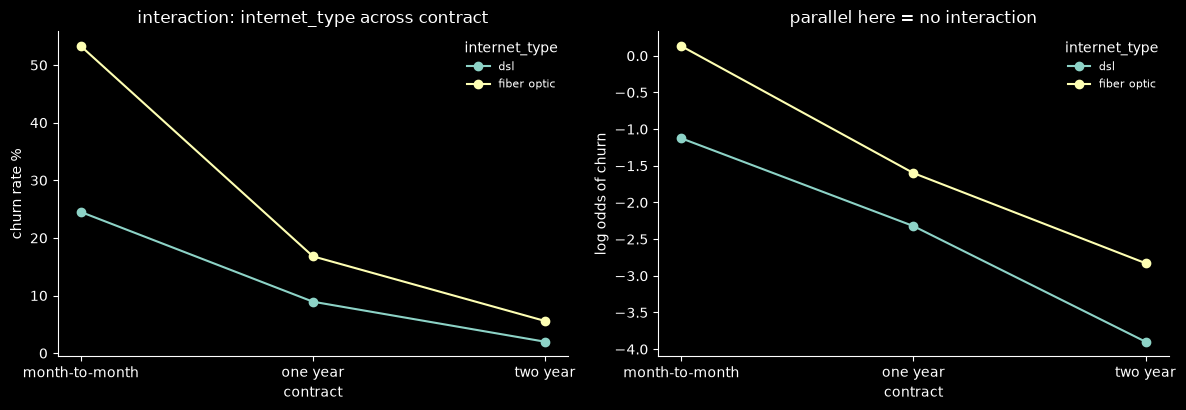

In [45]:
# The fiber penalty and the month-to-month penalty are the two largest raw effects
# in the data. How much of the fiber gap is fiber, and how much is contract mix?
query = """
SELECT
  se.internet_type,
  se.contract,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
  AND se.internet_service = TRUE
  AND se.internet_type <> 'cable'
GROUP BY
  se.internet_type,
  se.contract
"""

df = run_query(query)

rate_grid(df, rows="contract", cols="internet_type")
stratified(df, group="internet_type", strata="contract", a="fiber optic", b="dsl")
standardize(df, group="internet_type", strata="contract")
model_compare(df, group="internet_type", strata="contract")

plot_grid(df, rows="contract", cols="internet_type");
plot_interaction(df, rows="contract", cols="internet_type");

Fiber and DSL customers have different contract compositions, making contract type a potential source of confounding. Contract composition accounts for approximately `5.4` percentage points, or `25%`, of the crude `22.2-point` churn gap. However, after standardizing both groups to the same contract mix, a substantial `17.0-point` difference remains. The fiber-vs-DSL association is also reasonably consistent across contract types, with no strong evidence of interaction (homogeneity p = `0.073`; likelihood-ratio p = `0.104`). Therefore, a common adjusted effect is reasonable: fiber customers have approximately `2.15` times the churn rate of DSL customers after accounting for contract mix, while the logistic model estimates `1.91` times the odds of churn.

## Streaming x Age 

churn rate: streaming_band x age_group   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

age_group              0          1-2            3   |         all 
-------------------------------------------------------------------
non-senior  20.8 (1,182) 24.5 (1,156) 24.3 (1,440)   | 23.3 (3,778) 
senior        35.8 (246)   39.9 (541)   30.1 (153)   |  37.2 (940) 
-------------------------------------------------------------------
all         23.4 (1,428) 29.4 (1,697) 24.9 (1,593)   | 26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across age_group); last line = share of all customers

age_group              0          1-2            3   |         all 
-------------------------------------------------------------------
non-senior          82.8         68.1         90.4   |       80.1  
senior              17.2         31.9          9.6   |       19.9  
-------------------------------------------------------------------
a

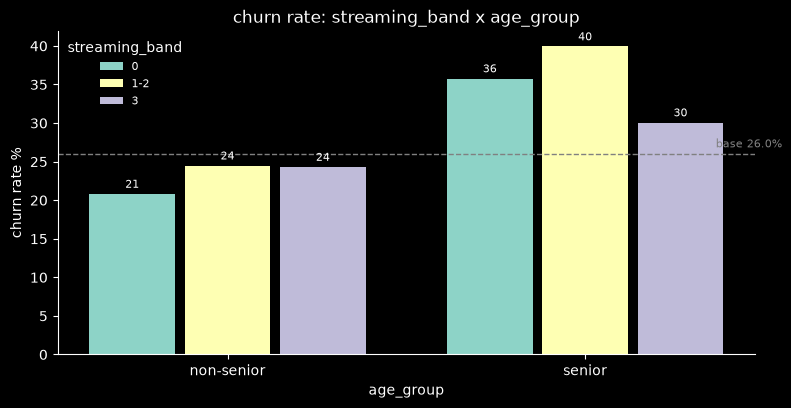

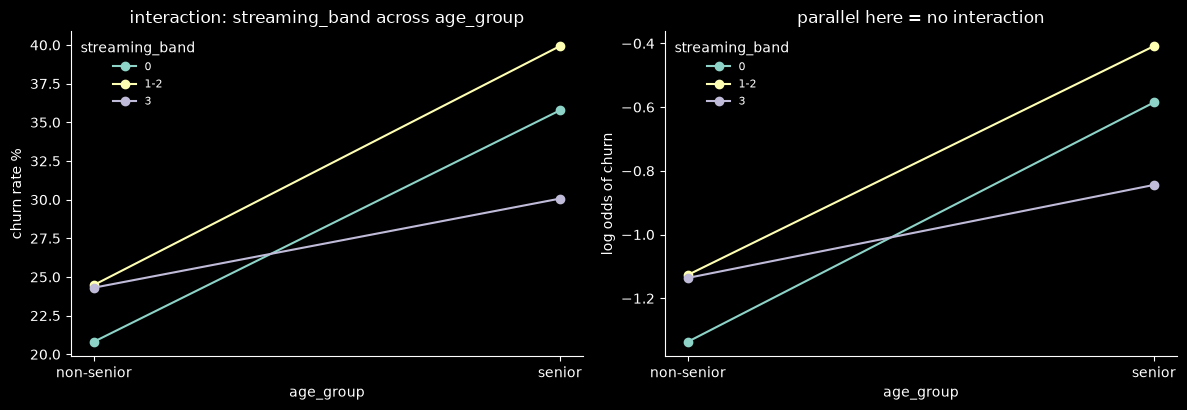

In [46]:
# Streaming was non-monotonic overall (1-2 services worst). Does that hold
# once age is held constant, or were the streaming bands just carrying a
# different age mix? Internet customers only, since streaming needs internet.
query = """
SELECT
  IF(age < 65, 'non-senior', 'senior') AS age_group,
  CASE
    WHEN streams = 0 THEN '0'
    WHEN streams <= 2 THEN '1-2'
    ELSE '3'
  END AS streaming_band,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners
FROM
  (
    SELECT
      d.age,
      st.churn_label,
      CAST(se.streaming_tv AS INT64) + CAST(se.streaming_movies AS INT64) + CAST(se.streaming_music AS INT64) AS streams
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
      JOIN `dbt_dev.stg_telco__demographics` d USING (customer_id)
    WHERE
      se.tenure_in_months > 3
      AND se.internet_service = TRUE
  )
GROUP BY
  age_group,
  streaming_band
"""

df = run_query(query)
df["streaming_band"] = band(df["streaming_band"], ["0", "1-2", "3"])

rate_grid(df, rows="age_group", cols="streaming_band")
stratified(df, group="streaming_band", strata="age_group", a="1-2", b="0")
standardize(df, group="streaming_band", strata="age_group")
model_compare(df, group="streaming_band", strata="age_group")

plot_grid(df, rows="age_group", cols="streaming_band");
plot_interaction(df, rows="age_group", cols="streaming_band");

## Dependents x Age

churn rate: dependents x age_group   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

age_group    has dependents   no dependents   |            all 
---------------------------------------------------------------
non-senior      4.0 (1,437)    24.2 (3,567)   |   18.4 (5,004) 
senior            14.1 (71)*     37.3 (917)   |     35.6 (988) 
---------------------------------------------------------------
all             4.4 (1,508)    26.9 (4,484)   |   21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across age_group); last line = share of all customers

age_group    has dependents   no dependents   |            all 
---------------------------------------------------------------
non-senior             95.3            79.5   |          83.5  
senior                  4.7            20.5   |          16.5  
---------------------------------------------------------------
all                    25.2            74.8   |    

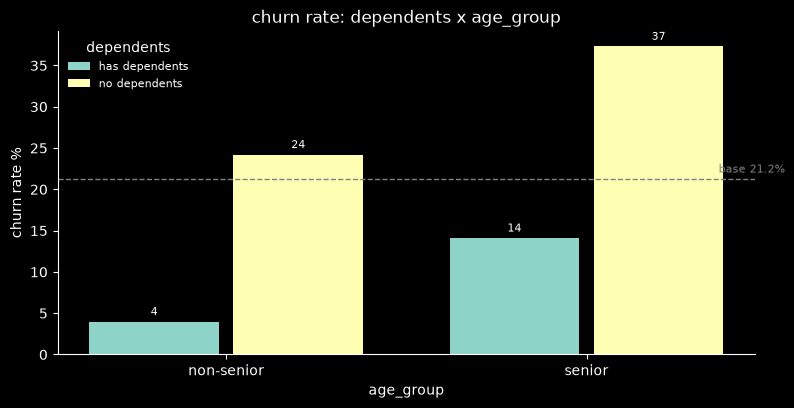

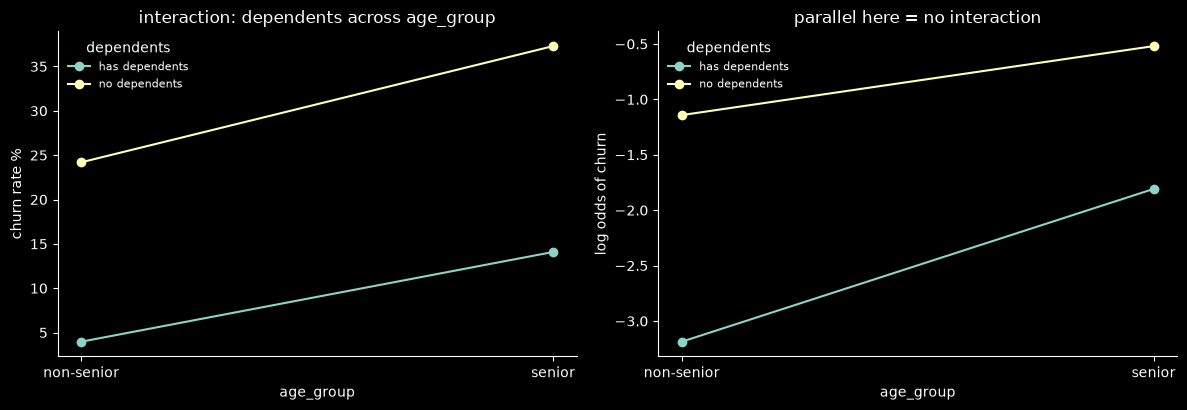

In [47]:
# Zero dependents was the single largest demographic gap (6.2x). Seniors are both
# likelier to churn and likelier to have no dependents - is the dependents effect
# the same size once age is held constant?
query = """
SELECT
  IF(d.age < 65, 'non-senior', 'senior') AS age_group,
  IF(
    d.number_of_dependents = 0,
    'no dependents',
    'has dependents'
  ) AS dependents,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  age_group,
  dependents
"""

df = run_query(query)

rate_grid(df, rows="age_group", cols="dependents")
stratified(df, group="dependents", strata="age_group", a="no dependents", b="has dependents")
standardize(df, group="dependents", strata="age_group")
model_compare(df, group="dependents", strata="age_group")

plot_grid(df, rows="age_group", cols="dependents");
plot_interaction(df, rows="age_group", cols="dependents");

## Age x Married

churn rate: age_group x marital   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

marital        non-senior       senior   |         all 
-------------------------------------------------------
married      14.7 (2,673)   31.3 (536)   | 17.5 (3,209) 
not married  22.7 (2,331)   40.7 (452)   | 25.6 (2,783) 
-------------------------------------------------------
all          18.4 (5,004)   35.6 (988)   | 21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across marital); last line = share of all customers

marital        non-senior       senior   |         all 
-------------------------------------------------------
married              53.4         54.3   |       53.6  
not married          46.6         45.7   |       46.4  
-------------------------------------------------------
all                  83.5         16.5   |      100.0  

share of all churners %: the grid sums to 100 (where the volume sits)

marital      

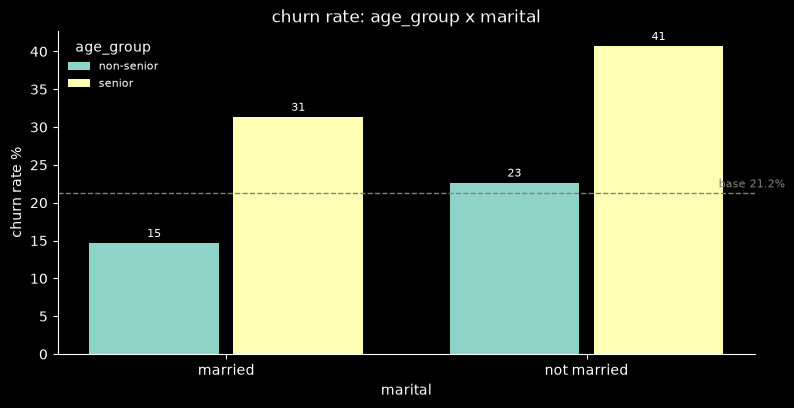

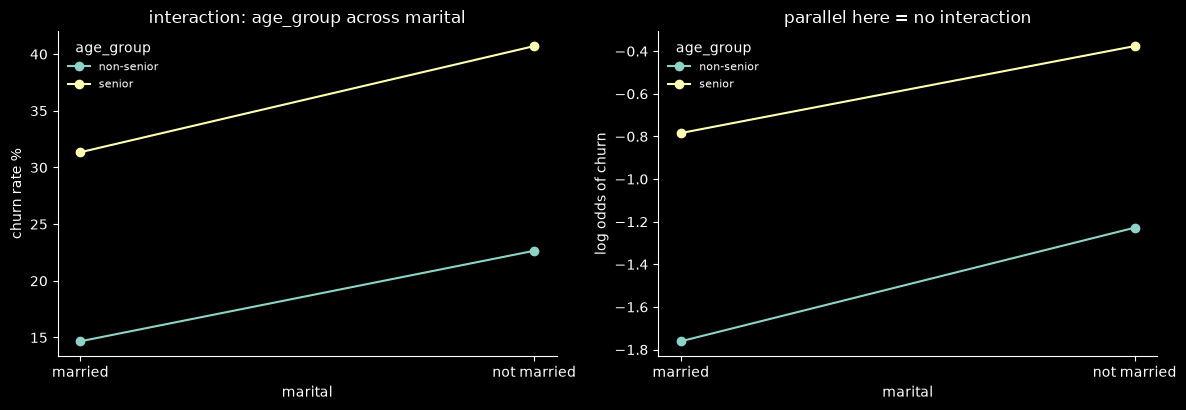

In [48]:
# Marriage and age are correlated, and both moved churn on their own. Does the
# age gap survive inside each married group, and is it the same size in both?
query = """
SELECT
  IF(d.age < 65, 'non-senior', 'senior') AS age_group,
  IF(d.married, 'married', 'not married') AS marital,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  age_group,
  marital
"""

df = run_query(query)

rate_grid(df, rows="marital", cols="age_group")
stratified(df, group="age_group", strata="marital", a="senior", b="non-senior")
standardize(df, group="age_group", strata="marital")
model_compare(df, group="age_group", strata="marital")

plot_grid(df, rows="marital", cols="age_group");
plot_interaction(df, rows="marital", cols="age_group");

## Tenure x Contract

churn rate: contract x tenure_band   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

tenure_band   month-to-month        one year        two year   |            all 
--------------------------------------------------------------------------------
4-12              47.1 (910)       9.2 (120)       0.0 (105)   |   38.8 (1,135) 
13-24             40.5 (686)       7.4 (215)       0.0 (123)   |   28.7 (1,024) 
25-48             36.9 (715)      10.1 (546)       1.8 (333)   |   20.4 (1,594) 
49+               30.1 (296)      12.8 (643)     3.2 (1,300)   |    9.5 (2,239) 
--------------------------------------------------------------------------------
all             40.7 (2,607)    10.8 (1,524)     2.6 (1,861)   |   21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across tenure_band); last line = share of all customers

tenure_band   month-to-month        one year        two year   |            all 
------------------------

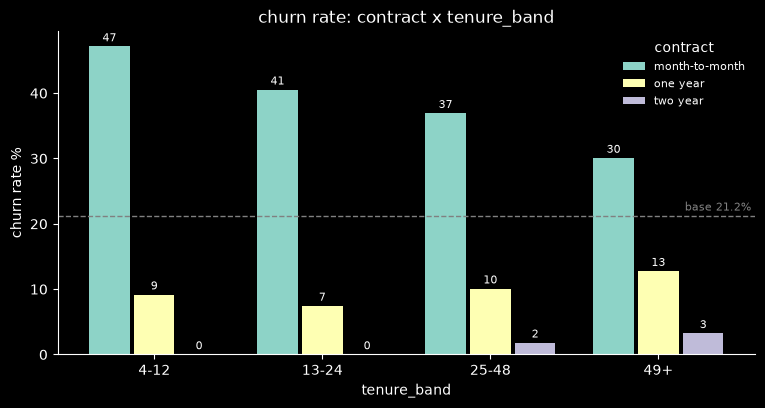

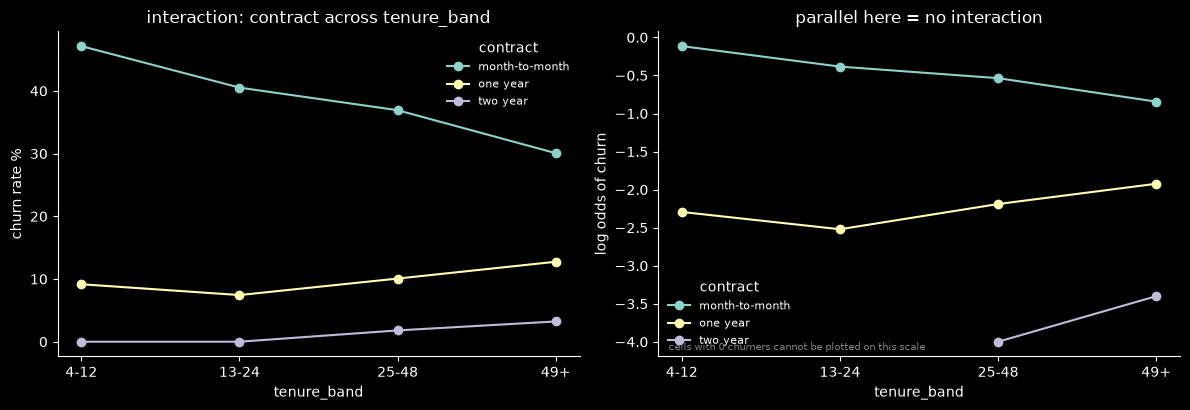

In [49]:
# Tenure and contract both look like commitment. Does churn still fall with tenure
# once contract is held constant, or was the tenure curve just contract mix?
query = """
SELECT
  se.contract,
  CASE
    WHEN se.tenure_in_months <= 12 THEN '4-12'
    WHEN se.tenure_in_months <= 24 THEN '13-24'
    WHEN se.tenure_in_months <= 48 THEN '25-48'
    ELSE '49+'
  END AS tenure_band,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  se.contract,
  tenure_band
"""

df = run_query(query)
df["tenure_band"] = band(df["tenure_band"], ["4-12", "13-24", "25-48", "49+"])

rate_grid(df, rows="tenure_band", cols="contract")
stratified(df, group="contract", strata="tenure_band", a="month-to-month", b="two year")
standardize(df, group="contract", strata="tenure_band")
model_compare(df, group="contract", strata="tenure_band")

plot_grid(df, rows="tenure_band", cols="contract");
plot_interaction(df, rows="tenure_band", cols="contract");

# Follow-up questions

Same reading as the section above. Two notes that apply throughout:

- `total_charges` is close to tenure x price, so it cannot separate a price
  effect from a tenure effect - `monthly_charge` is the price variable, and
  `total_charges` is shown only to confirm it re-tells tenure.
- there is **no customer without service**: every customer holds phone,
  internet or both, so the usage cuts compare `phone only` and `internet only`
  against `both` rather than against nothing.

## Internet type x Price

churn rate: internet_type x price_band   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

price_band         cable          dsl  fiber optic   |         all 
-------------------------------------------------------------------
1 <58         19.3 (295)   19.4 (644)            -   |  19.4 (939) 
2 58-75       10.0 (219)    9.5 (472)   45.8 (216)   |  18.3 (907) 
3 75-88       19.4 (124)    4.2 (238)   41.2 (646)   | 29.8 (1,008) 
4 88-100       42.2 (45)*    1.8 (57)*  36.2 (867)   |  34.5 (969) 
5 100+        100.0 (11)*           -   26.7 (884)   |  27.6 (895) 
-------------------------------------------------------------------
all           19.2 (694) 12.8 (1,411) 35.0 (2,613)   | 26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across price_band); last line = share of all customers

price_band         cable          dsl  fiber optic   |         all 
-------------------------------------------------------------------


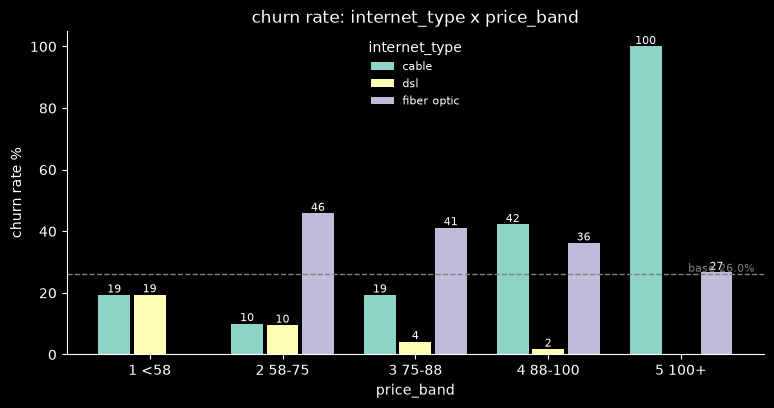

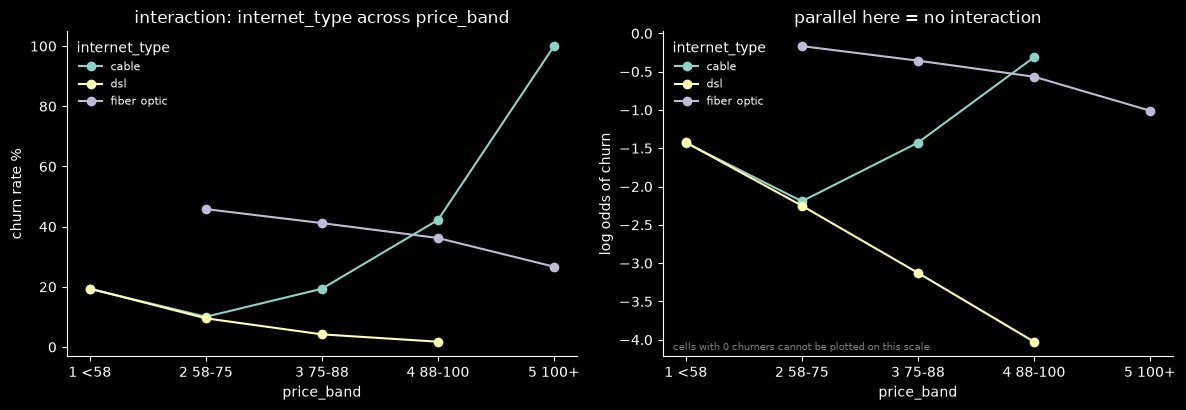

In [50]:
# Is fiber's churn just its price tag? Price bands are the monthly_charge
# quintiles among internet customers (edges 58 / 75 / 88 / 100).
query = """
SELECT
  internet_type,
  price_band,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners
FROM
  (
    SELECT
      se.internet_type,
      st.churn_label,
      CASE
        WHEN se.monthly_charge < 58 THEN '1 <58'
        WHEN se.monthly_charge < 75 THEN '2 58-75'
        WHEN se.monthly_charge < 88 THEN '3 75-88'
        WHEN se.monthly_charge < 100 THEN '4 88-100'
        ELSE '5 100+'
      END AS price_band
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.tenure_in_months > 3
      AND se.internet_service = TRUE
  )
GROUP BY
  internet_type,
  price_band
"""

df = run_query(query)

rate_grid(df, rows="price_band", cols="internet_type")
stratified(df, group="internet_type", strata="price_band", a="fiber optic", b="dsl")
standardize(df, group="internet_type", strata="price_band")

# the products barely share a price range, so the model is fitted only on the
# bands where all three are actually sold - elsewhere there is nothing to compare
overlap = [b for b, g in df.groupby("price_band") if g["internet_type"].nunique() == 3]
print(f"\nbands where all three types are sold: {overlap}")
model_compare(df[df["price_band"].isin(overlap)], group="internet_type", strata="price_band")

plot_grid(df, rows="price_band", cols="internet_type");
plot_interaction(df, rows="price_band", cols="internet_type");

## Internet type x Total charges

avg tenure by spend band: 1 <1k 10 months,  2 1-2.5k 28 months,  3 2.5-4.5k 49 months,  4 4.5k+ 66 months
churn rate: internet_type x spend_band   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

spend_band         cable          dsl  fiber optic   |         all 
-------------------------------------------------------------------
1 <1k         30.6 (193)   26.1 (403)   61.7 (441)   | 42.0 (1,037) 
2 1-2.5k      21.2 (203)   11.0 (399)   47.8 (582)   | 30.8 (1,184) 
3 2.5-4.5k    11.7 (180)    6.8 (367)   33.2 (554)   | 20.9 (1,101) 
4 4.5k+        8.5 (118)    2.9 (242) 17.5 (1,036)   | 14.2 (1,396) 
-------------------------------------------------------------------
all           19.2 (694) 12.8 (1,411) 35.0 (2,613)   | 26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across spend_band); last line = share of all customers

spend_band         cable          dsl  fiber optic   |         all 
---------------------------

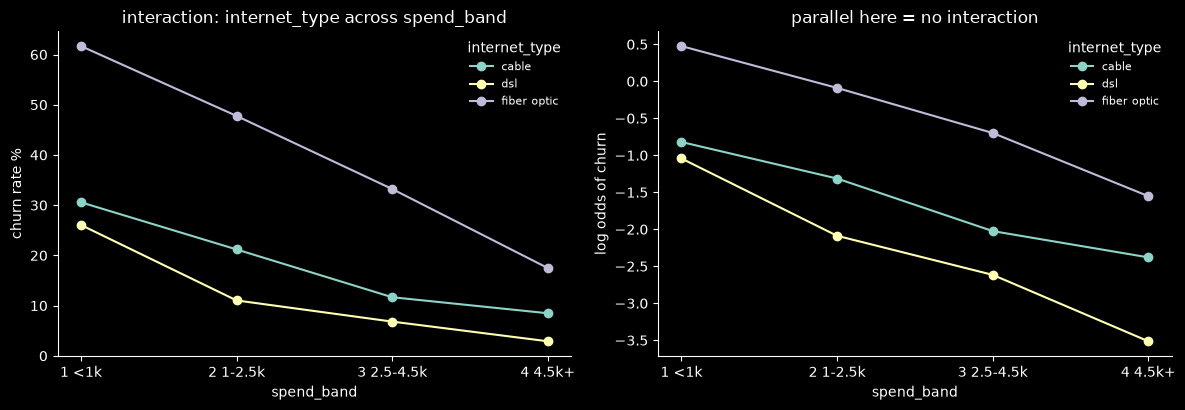

In [51]:
# total_charges is roughly tenure x price, so this cut should re-tell tenure
# rather than price. Bands are total_charges quartiles.
query = """
SELECT
  internet_type,
  spend_band,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners,
  ROUND(AVG(tenure_in_months)) AS avg_tenure
FROM
  (
    SELECT
      se.internet_type,
      se.tenure_in_months,
      st.churn_label,
      CASE
        WHEN se.total_charges < 1000 THEN '1 <1k'
        WHEN se.total_charges < 2500 THEN '2 1-2.5k'
        WHEN se.total_charges < 4500 THEN '3 2.5-4.5k'
        ELSE '4 4.5k+'
      END AS spend_band
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.tenure_in_months > 3
      AND se.internet_service = TRUE
  )
GROUP BY
  internet_type,
  spend_band
"""

df = run_query(query)

# average tenure per spend band - the check that this axis is really tenure
print("avg tenure by spend band: " + ",  ".join(
    f"{b} {g['avg_tenure'].mean():.0f} months" for b, g in df.groupby("spend_band")))

rate_grid(df, rows="spend_band", cols="internet_type")
stratified(df, group="internet_type", strata="spend_band", a="fiber optic", b="dsl")
plot_interaction(df, rows="spend_band", cols="internet_type");

## Internet type X Streaming

churn rate: internet_type x streaming_band   |   base 27.2%   |   4,024 customers, 1,096 churners

churn rate: rate% (n)   * = n<100

streaming_band           dsl  fiber optic   |         all 
----------------------------------------------------------
0                 15.2 (558)   32.8 (610)   | 24.4 (1,168) 
1                 11.2 (233)   40.7 (454)   |  30.7 (687) 
2                 12.6 (230)   38.4 (547)   |  30.8 (777) 
3                 10.5 (390) 31.9 (1,002)   | 25.9 (1,392) 
----------------------------------------------------------
all             12.8 (1,411) 35.0 (2,613)   | 27.2 (4,024) 

customer mix %: each column sums to 100 (how the group spreads across streaming_band); last line = share of all customers

streaming_band           dsl  fiber optic   |         all 
----------------------------------------------------------
0                       39.5         23.3   |       29.0  
1                       16.5         17.4   |       17.1  
2                       16.3   

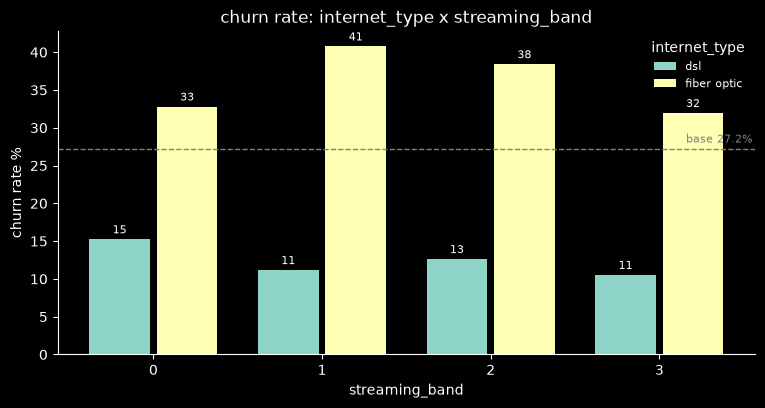

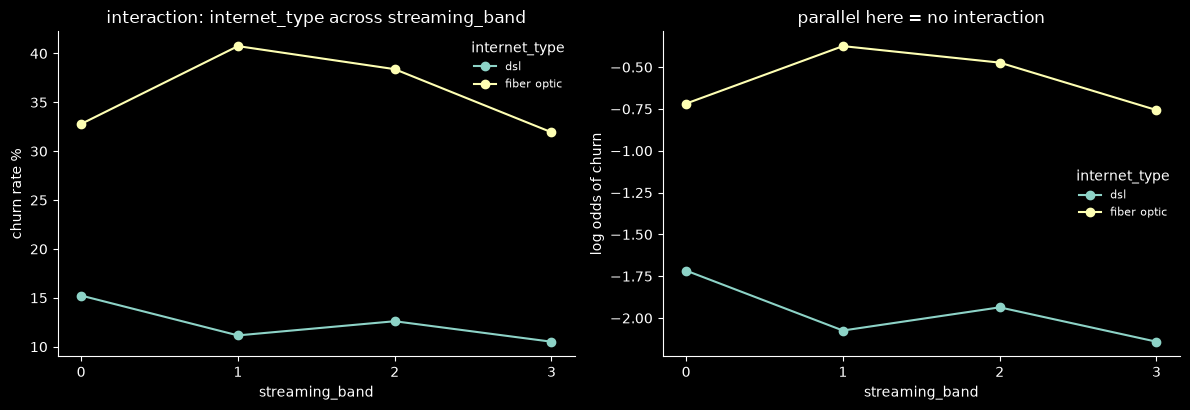

In [68]:
# Is fiber effect just a result of higher streaming?
query = """
SELECT
  internet_type,
  CASE
    WHEN streams = 0 THEN '0'
    WHEN streams = 1 THEN '1'
    WHEN streams = 2 THEN '2'
    ELSE '3'
  END AS streaming_band,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners
FROM
  (
    SELECT
      se.internet_type,
      st.churn_label,
      CAST(se.streaming_tv AS INT64) + CAST(se.streaming_movies AS INT64) + CAST(se.streaming_music AS INT64) AS streams
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.tenure_in_months > 3
      AND se.internet_service = TRUE
      AND se.internet_type <> 'cable'
  )
GROUP BY
  internet_type,
  streaming_band
"""

df = run_query(query)
df["streaming_band"] = band(df["streaming_band"], ["0", "1","2", "3"])

rate_grid(df, rows="streaming_band", cols="internet_type")
stratified(df, group="internet_type", strata="streaming_band", a="fiber optic", b="dsl")
standardize(df, group="internet_type", strata="streaming_band")
model_compare(df, group="internet_type", strata="streaming_band")

plot_grid(df, rows="streaming_band", cols="internet_type");
plot_interaction(df, rows="streaming_band", cols="internet_type");

## Referrals

In [53]:
# Churn by whether the customer referred anyone, and by how many.
query = """
SELECT
  CASE
    WHEN se.number_of_referrals = 0 THEN '0'
    WHEN se.number_of_referrals = 1 THEN '1'
    WHEN se.number_of_referrals <= 3 THEN '2-3'
    ELSE '4+'
  END AS referrals,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  referrals
"""

df = run_query(query)
df["referrals"] = band(df["referrals"], ["0", "1", "2-3", "4+"])
rate_table(df, group="referrals", reference="0")

referrals   |   base 21.2%   |   5,992 customers, 1,272 churners

referrals           rate % (95% CI)  % of cust  % of churn          diff pp (95% CI)   ratio   excess     p adj
---------------------------------------------------------------------------------------------------------------
4+                   3.3 (2.6, 4.3)       26.5         4.2      -22.0 (-23.7, -20.1)   0.13x     -349   4.2e-76   n=1,588
2-3                10.7 (8.2, 13.8)        7.8         3.9      -14.6 (-17.6, -11.1)   0.42x      -68   3.7e-12   n=468
0                 25.3 (23.8, 26.9)       49.2        58.6                         -       -        -         -   n=2,949
1                 42.9 (39.8, 46.0)       16.5        33.3      +17.6 (+14.1, +21.0)   1.69x     +173   2.9e-25   n=987
---------------------------------------------------------------------------------------------------------------
reference: 0   omnibus chi2=640.4, dof=3, p=1.76e-138   * = n<100, directional only


churn rate: referrer x tenure_band   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

tenure_band             0            1          2-3           4+   |         all 
---------------------------------------------------------------------------------
4-12           40.0 (788)   64.6 (147)    23.6 (55)*  11.7 (145)   | 38.8 (1,135) 
13-24          29.3 (604)   56.6 (175)    15.8 (57)*   4.8 (188)   | 28.7 (1,024) 
25-48          20.7 (823)   48.5 (268)   12.4 (113)    2.8 (390)   | 20.4 (1,594) 
49+            11.4 (734)   24.9 (397)    5.8 (243)    1.8 (865)   | 9.5 (2,239) 
---------------------------------------------------------------------------------
all          25.3 (2,949)   42.9 (987)   10.7 (468)  3.3 (1,588)   | 21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across tenure_band); last line = share of all customers

tenure_band             0            1          2-3           4+   |         all 
-----------

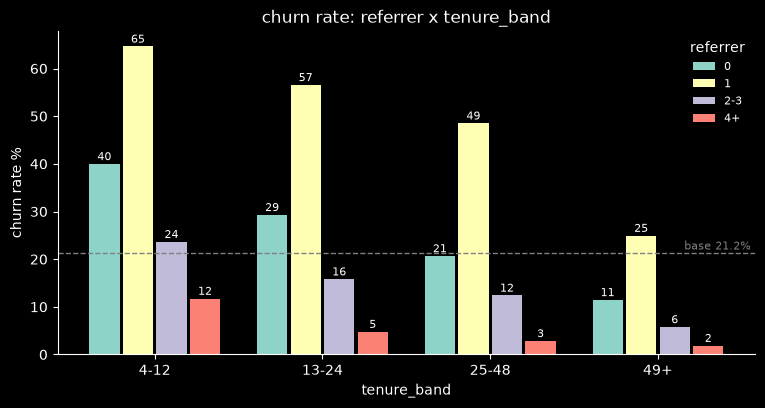

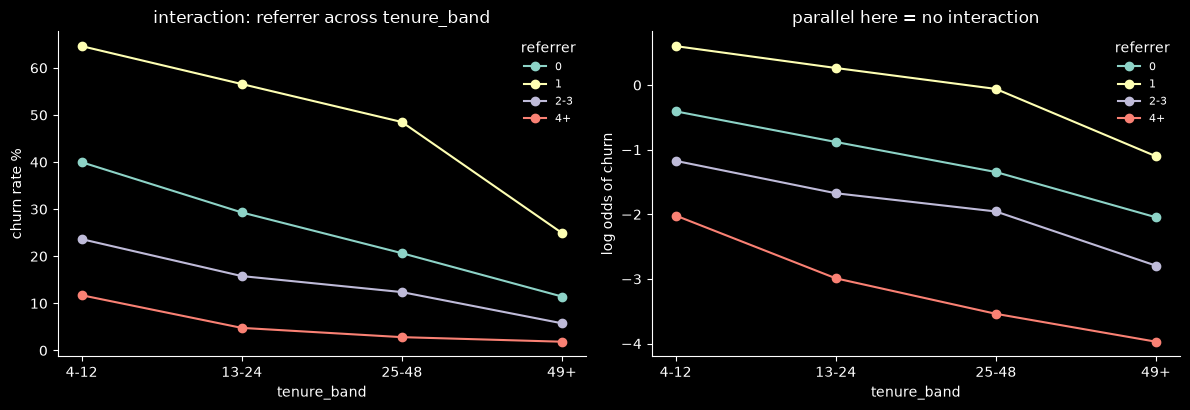

In [71]:
# Referrals accumulate with time on the books, so the cut above may be tenure
# wearing a different hat - does it survive holding tenure constant?
query = """
SELECT
  CASE
      WHEN se.number_of_referrals = 0 THEN '0'
      WHEN se.number_of_referrals = 1 THEN '1'
      WHEN se.number_of_referrals <= 3 THEN '2-3'
      ELSE '4+'
    END AS referrer,
  CASE
    WHEN se.tenure_in_months <= 12 THEN '4-12'
    WHEN se.tenure_in_months <= 24 THEN '13-24'
    WHEN se.tenure_in_months <= 48 THEN '25-48'
    ELSE '49+'
  END AS tenure_band,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  referrer,
  tenure_band
"""

df = run_query(query)
df["tenure_band"] = band(df["tenure_band"], ["4-12", "13-24", "25-48", "49+"])

rate_grid(df, rows="tenure_band", cols="referrer")
stratified(df, group="referrer", strata="tenure_band", a="0", b="4+")
stratified(df, group="referrer", strata="tenure_band", a="0", b="1")
standardize(df, group="referrer", strata="tenure_band")
model_compare(df, group="referrer", strata="tenure_band")

plot_grid(df, rows="tenure_band", cols="referrer");
plot_interaction(df, rows="tenure_band", cols="referrer");

## Gender x Age

churn rate: gender x age_group   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

age_group         female         male   |         all 
------------------------------------------------------
non-senior  18.7 (2,491) 18.1 (2,513)   | 18.4 (5,004) 
senior        35.1 (482)   36.2 (506)   |  35.6 (988) 
------------------------------------------------------
all         21.4 (2,973) 21.1 (3,019)   | 21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across age_group); last line = share of all customers

age_group         female         male   |         all 
------------------------------------------------------
non-senior          83.8         83.2   |       83.5  
senior              16.2         16.8   |       16.5  
------------------------------------------------------
all                 49.6         50.4   |      100.0  

share of all churners %: the grid sums to 100 (where the volume sits)

age_group         female 

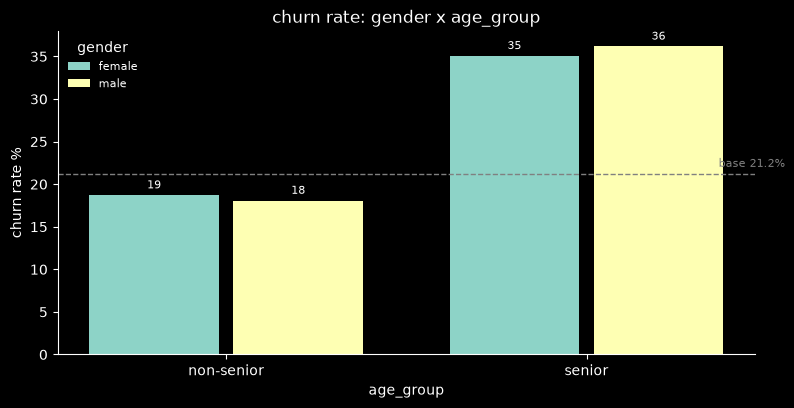

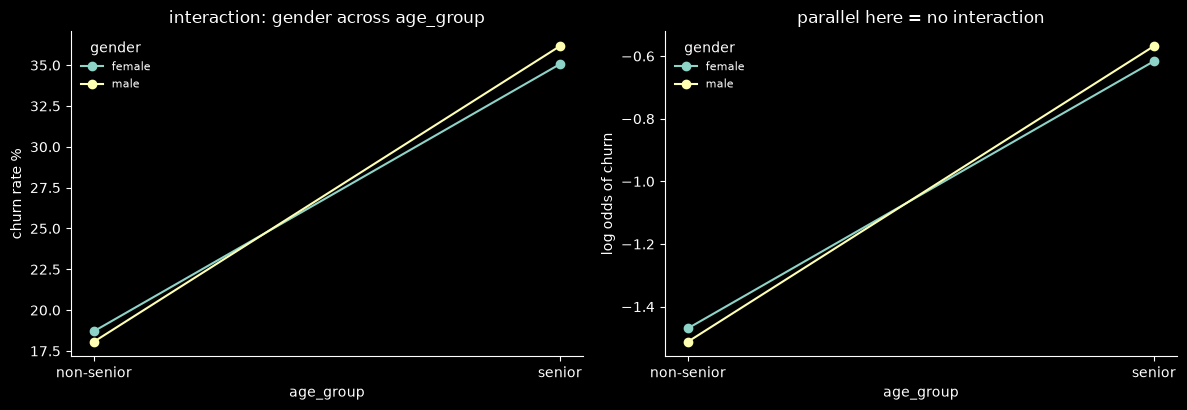

In [55]:
# Gender was flat overall. Does it stay flat inside each age group, or do the
# two age groups hide gender effects pointing opposite ways?
query = """
SELECT
  d.gender,
  IF(d.age < 65, 'non-senior', 'senior') AS age_group,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  d.gender,
  age_group
"""

df = run_query(query)

rate_grid(df, rows="age_group", cols="gender")
stratified(df, group="gender", strata="age_group", a="male", b="female")
standardize(df, group="gender", strata="age_group")
model_compare(df, group="gender", strata="age_group")

plot_grid(df, rows="age_group", cols="gender");
plot_interaction(df, rows="age_group", cols="gender");

## Geography: city and zip population

1,105 cities, largest 252, median 4 customers
29 of 1,105 city groups have n>=20; 4 sit outside the 95% band (14%, about 1 expected by chance)


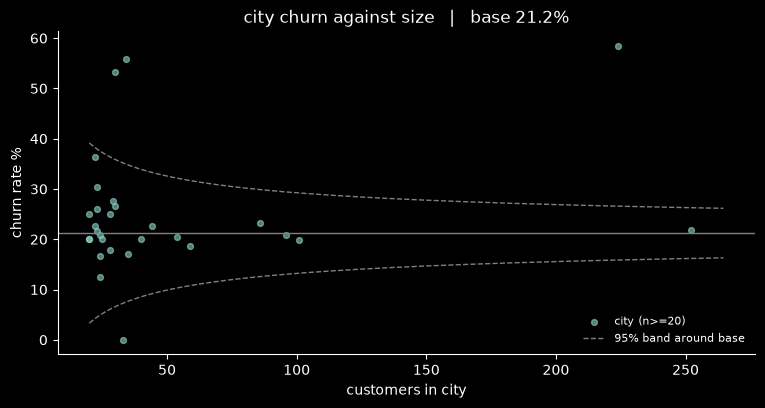

In [56]:
# Cities are far too thin to rank: 1,105 of them, only a handful above n=100.
# The funnel shows each city against the spread expected from its size alone -
# points inside the band are indistinguishable from the base rate.
query = """
SELECT
  l.city,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__location` l
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  l.city
"""

cities = run_query(query)
print(f"{len(cities):,} cities, largest {cities['customers'].max()}, "
      f"median {cities['customers'].median():.0f} customers")
funnel_plot(cities, unit="city", min_n=20);

In [57]:
# The usable geographic axis is zip population as a density proxy:
# rural <5k, suburban 5-25k, urban 25k+ (population is per zip, not per city).
query = """
SELECT
  CASE
    WHEN p.population < 5000 THEN '1 rural <5k'
    WHEN p.population < 25000 THEN '2 suburban 5-25k'
    ELSE '3 urban 25k+'
  END AS density,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__location` l
  JOIN `dbt_dev.stg_telco__population` p USING (zip_code)
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  density
"""

df = run_query(query)
rate_table(df, group="density", reference="1 rural <5k")

density   |   base 21.2%   |   5,992 customers, 1,272 churners

density                    rate % (95% CI)  % of cust  % of churn          diff pp (95% CI)   ratio   excess     p adj
----------------------------------------------------------------------------------------------------------------------
2 suburban 5-25k         18.4 (16.6, 20.4)       27.3        23.7         -0.5 (-3.1, +2.0)   0.97x       -9      0.69   n=1,633
1 rural <5k              19.0 (17.3, 20.8)       32.7        29.2                         -       -        -         -   n=1,962
3 urban 25k+             25.0 (23.3, 26.8)       40.0        47.1         +6.0 (+3.6, +8.5)   1.32x     +145   3.9e-06   n=2,397
----------------------------------------------------------------------------------------------------------------------
reference: 1 rural <5k   omnibus chi2=33.9, dof=2, p=4.25e-08   * = n<100, directional only


## City x Internet type

churn rate: internet_type x density   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

density                  cable          dsl  fiber optic   |         all 
-------------------------------------------------------------------------
1 rural <5k         16.1 (230)   10.6 (473)   32.8 (842)   | 23.5 (1,545) 
2 suburban 5-25k    13.4 (179)   13.8 (378)   30.9 (699)   | 23.2 (1,256) 
3 urban 25k+        25.3 (285)   14.1 (560) 39.5 (1,072)   | 29.9 (1,917) 
-------------------------------------------------------------------------
all                 19.2 (694) 12.8 (1,411) 35.0 (2,613)   | 26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across density); last line = share of all customers

density                  cable          dsl  fiber optic   |         all 
-------------------------------------------------------------------------
1 rural <5k               33.1         33.5         32.2   |       32.7  
2 suburban 5

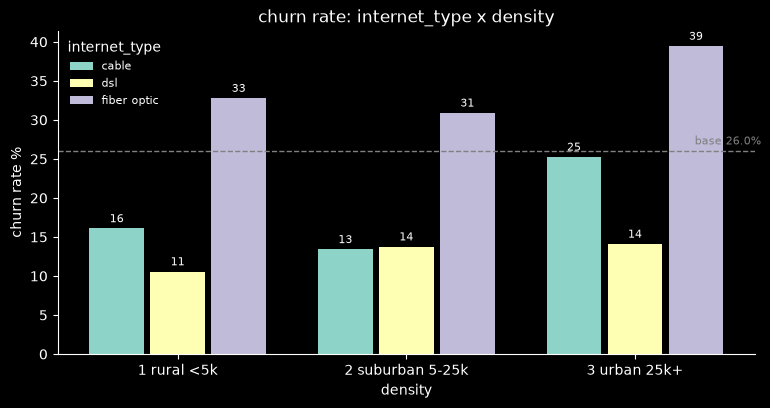

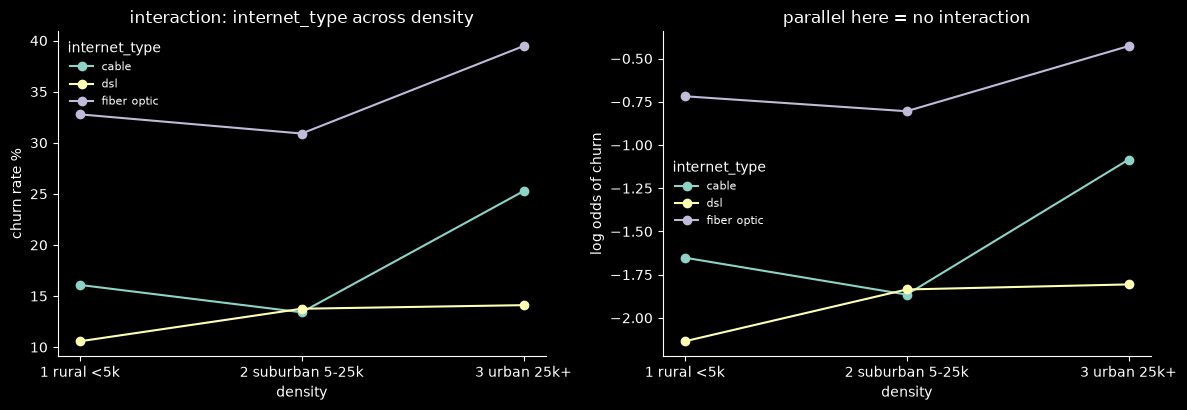

In [58]:
# Per-city x internet-type cells are single digits, so the city axis is the
# density class again: is the urban churn premium a market effect, or just
# fiber being sold where the people are?
query = """
SELECT
  se.internet_type,
  CASE
    WHEN p.population < 5000 THEN '1 rural <5k'
    WHEN p.population < 25000 THEN '2 suburban 5-25k'
    ELSE '3 urban 25k+'
  END AS density,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__location` l
  JOIN `dbt_dev.stg_telco__population` p USING (zip_code)
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
  AND se.internet_service = TRUE
GROUP BY
  se.internet_type,
  density
"""

df = run_query(query)

rate_grid(df, rows="density", cols="internet_type")
stratified(df, group="internet_type", strata="density", a="fiber optic", b="dsl")
standardize(df, group="internet_type", strata="density")
model_compare(df, group="internet_type", strata="density")

plot_grid(df, rows="density", cols="internet_type");
plot_interaction(df, rows="density", cols="internet_type");

## Usage: phone, internet, both

In [59]:
# Nobody in this base holds neither service, so `both` is the reference and the
# comparison is against holding one service instead of two.
query = """
SELECT
  CASE
    WHEN se.phone_service
    AND se.internet_service THEN 'both'
    WHEN se.phone_service THEN 'phone only'
    ELSE 'internet only'
  END AS usage,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  usage
"""

df = run_query(query)
print("customers holding neither service:",
      run_query("""
SELECT COUNT(*) AS n
FROM `dbt_dev.stg_telco__services`
WHERE tenure_in_months > 3 AND NOT phone_service AND NOT internet_service
""")["n"].item())
rate_table(df, group="usage", reference="both")

customers holding neither service: 0
usage   |   base 21.2%   |   5,992 customers, 1,272 churners

usage                   rate % (95% CI)  % of cust  % of churn          diff pp (95% CI)   ratio   excess     p adj
-------------------------------------------------------------------------------------------------------------------
phone only               3.4 (2.5, 4.5)       21.3         3.4      -23.8 (-25.5, -22.1)   0.12x     -304   9.6e-73   n=1,274
internet only         17.7 (14.8, 21.0)        9.6         8.0        -9.5 (-12.7, -5.9)   0.65x      -55   1.1e-06   n=576
both                  27.2 (25.9, 28.6)       69.1        88.6                         -       -        -         -   n=4,142
-------------------------------------------------------------------------------------------------------------------
reference: both   omnibus chi2=335.7, dof=2, p=1.27e-73   * = n<100, directional only


## Usage x Internet type

churn rate: usage x internet_type   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

internet_type            both  internet only   |           all 
---------------------------------------------------------------
cable              20.1 (498)     16.8 (196)   |    19.2 (694) 
dsl              10.9 (1,031)     18.2 (380)   |  12.8 (1,411) 
fiber optic      35.0 (2,613)              -   |  35.0 (2,613) 
---------------------------------------------------------------
all              27.2 (4,142)     17.7 (576)   |  26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across internet_type); last line = share of all customers

internet_type            both  internet only   |           all 
---------------------------------------------------------------
cable                    12.0           34.0   |         14.7  
dsl                      24.9           66.0   |         29.9  
fiber optic              63.1            0.0   |

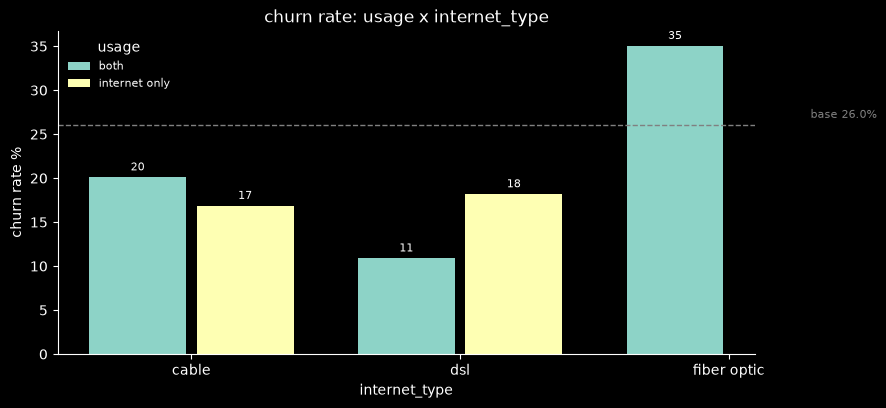

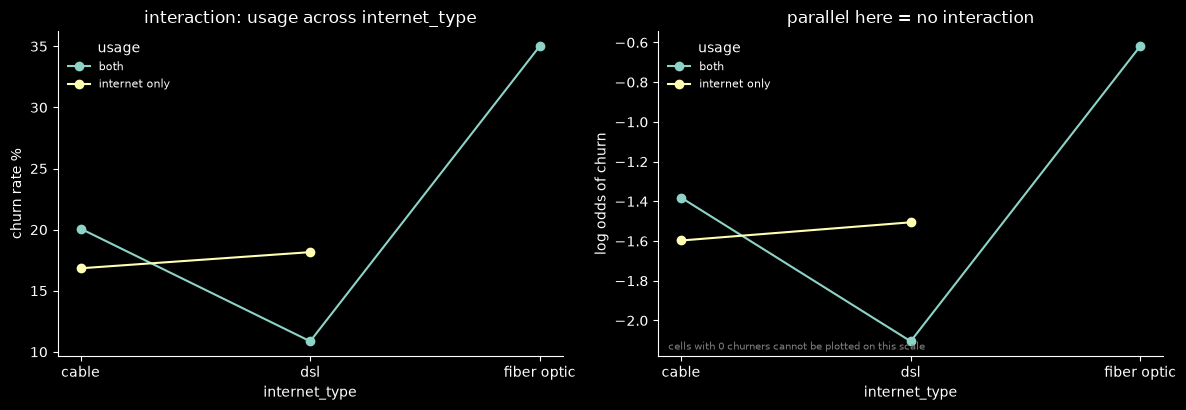

In [60]:
# Internet type only exists for internet holders, so this asks whether dropping
# the phone line matters differently depending on which internet they hold.
query = """
SELECT
  IF(se.phone_service, 'both', 'internet only') AS usage,
  se.internet_type,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
  AND se.internet_service = TRUE
GROUP BY
  usage,
  se.internet_type
"""

df = run_query(query)

rate_grid(df, rows="internet_type", cols="usage")
stratified(df, group="usage", strata="internet_type", a="both", b="internet only")
standardize(df, group="usage", strata="internet_type")
model_compare(df, group="usage", strata="internet_type")

plot_grid(df, rows="internet_type", cols="usage");
plot_interaction(df, rows="internet_type", cols="usage");

## Usage x Contract

churn rate: usage x contract   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

contract                  both  internet only     phone only   |           all 
-------------------------------------------------------------------------------
month-to-month    45.6 (2,072)     34.4 (247)     10.8 (288)   |  40.7 (2,607) 
one year          13.9 (1,026)      9.4 (149)      2.0 (349)   |  10.8 (1,524) 
two year           3.8 (1,044)      1.7 (180)      0.8 (637)   |   2.6 (1,861) 
-------------------------------------------------------------------------------
all               27.2 (4,142)     17.7 (576)    3.4 (1,274)   |  21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across contract); last line = share of all customers

contract                  both  internet only     phone only   |           all 
-------------------------------------------------------------------------------
month-to-month            50.0           4

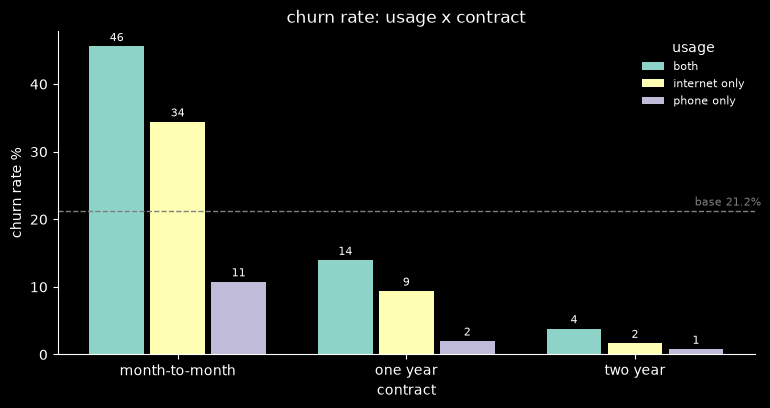

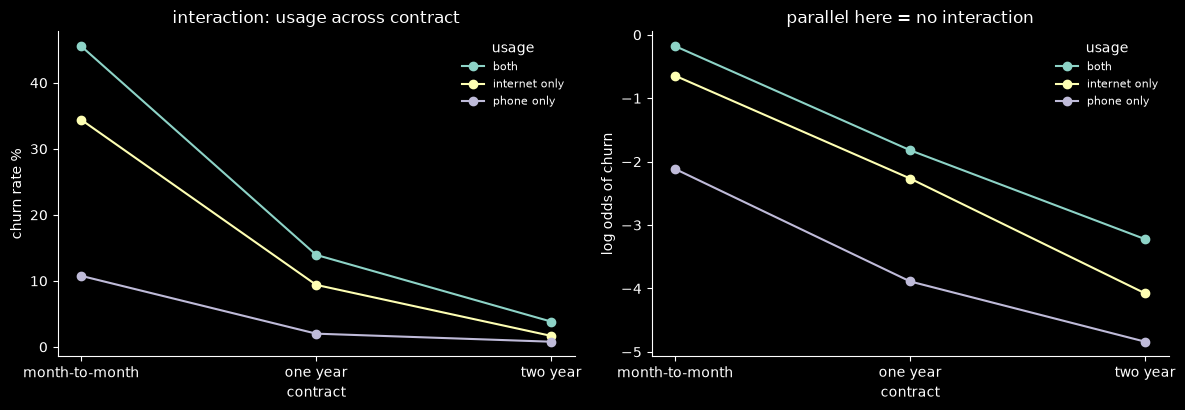

In [72]:
# Phone-only customers churn least - is that the thin bundle, or are they simply
# parked on long contracts?
query = """
SELECT
  CASE
    WHEN se.phone_service
    AND se.internet_service THEN 'both'
    WHEN se.phone_service THEN 'phone only'
    ELSE 'internet only'
  END AS usage,
  se.contract,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  usage,
  se.contract
"""

df = run_query(query)

rate_grid(df, rows="contract", cols="usage")
stratified(df, group="usage", strata="contract", a="both", b="phone only")
stratified(df, group="usage", strata="contract", a="both", b="internet only")
stratified(df, group="usage", strata="contract", a="internet only", b="phone only")
standardize(df, group="usage", strata="contract")
model_compare(df, group="usage", strata="contract")

plot_grid(df, rows="contract", cols="usage");
plot_interaction(df, rows="contract", cols="usage");

## Usage x Tenure

churn rate: usage x tenure_band   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

tenure_band            both  internet only     phone only   |           all 
----------------------------------------------------------------------------
4-12             50.3 (761)     31.0 (113)      8.4 (261)   |  38.8 (1,135) 
13-24            37.4 (695)      27.8 (90)*     3.8 (239)   |  28.7 (1,024) 
25-48          26.8 (1,090)     16.2 (167)      1.8 (337)   |  20.4 (1,594) 
49+            12.0 (1,596)      7.3 (206)      1.4 (437)   |   9.5 (2,239) 
----------------------------------------------------------------------------
all            27.2 (4,142)     17.7 (576)    3.4 (1,274)   |  21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across tenure_band); last line = share of all customers

tenure_band            both  internet only     phone only   |           all 
---------------------------------------------------------------

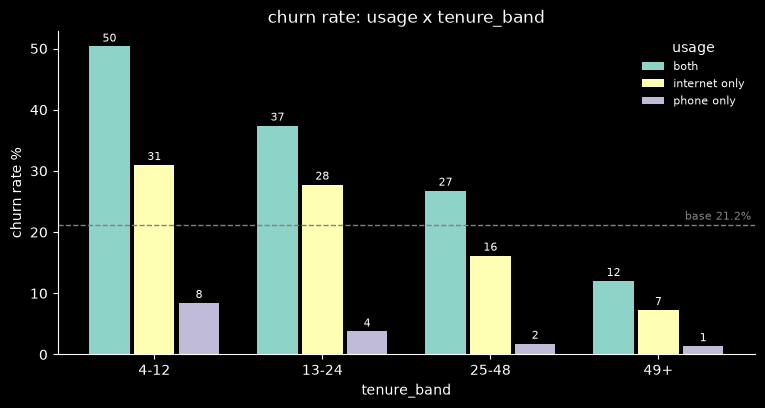

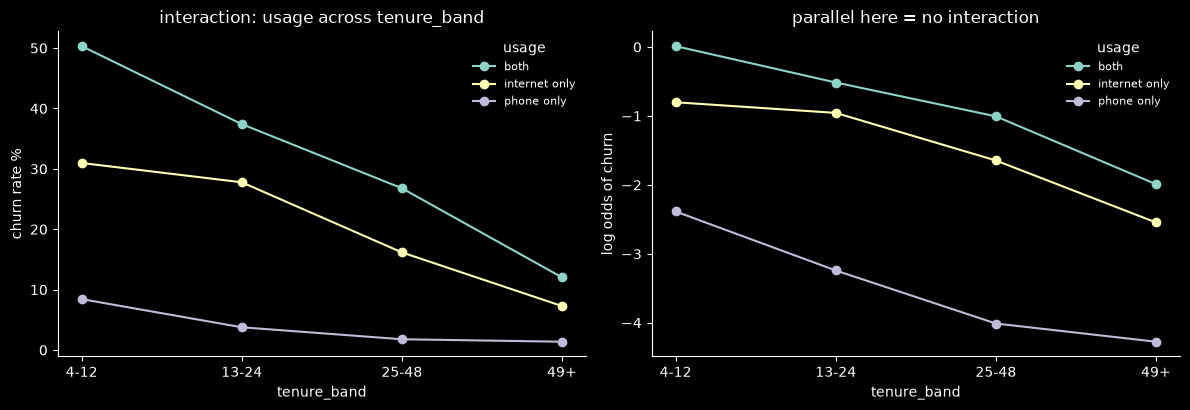

In [62]:
# Does the bundle gap hold at every stage of the lifecycle?
query = """
SELECT
  CASE
    WHEN se.phone_service
    AND se.internet_service THEN 'both'
    WHEN se.phone_service THEN 'phone only'
    ELSE 'internet only'
  END AS usage,
  CASE
    WHEN se.tenure_in_months <= 12 THEN '4-12'
    WHEN se.tenure_in_months <= 24 THEN '13-24'
    WHEN se.tenure_in_months <= 48 THEN '25-48'
    ELSE '49+'
  END AS tenure_band,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  usage,
  tenure_band
"""

df = run_query(query)
df["tenure_band"] = band(df["tenure_band"], ["4-12", "13-24", "25-48", "49+"])

rate_grid(df, rows="tenure_band", cols="usage")
stratified(df, group="usage", strata="tenure_band", a="both", b="phone only")
standardize(df, group="usage", strata="tenure_band")
model_compare(df, group="usage", strata="tenure_band")

plot_grid(df, rows="tenure_band", cols="usage");
plot_interaction(df, rows="tenure_band", cols="usage");

## Usage x Age

churn rate: usage x age_group   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

age_group             both  internet only     phone only   |           all 
---------------------------------------------------------------------------
non-senior    24.4 (3,287)     15.5 (491)    3.3 (1,226)   |  18.4 (5,004) 
senior          37.9 (855)      30.6 (85)*      4.2 (48)*  |    35.6 (988) 
---------------------------------------------------------------------------
all           27.2 (4,142)     17.7 (576)    3.4 (1,274)   |  21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across age_group); last line = share of all customers

age_group             both  internet only     phone only   |           all 
---------------------------------------------------------------------------
non-senior            79.4           85.2           96.2   |         83.5  
senior                20.6           14.8            3.8   |         16.5  


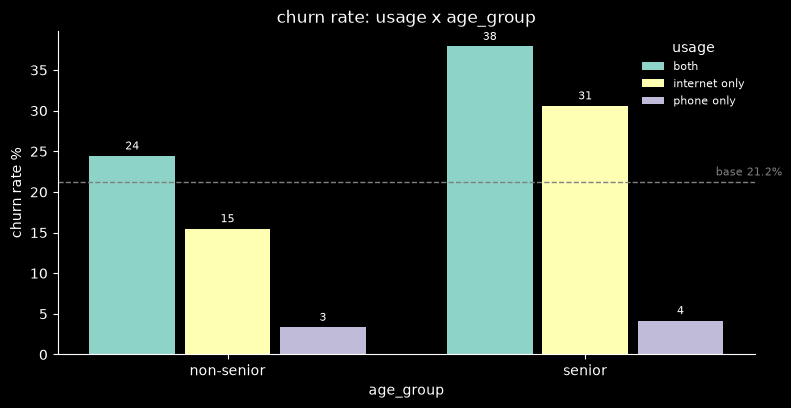

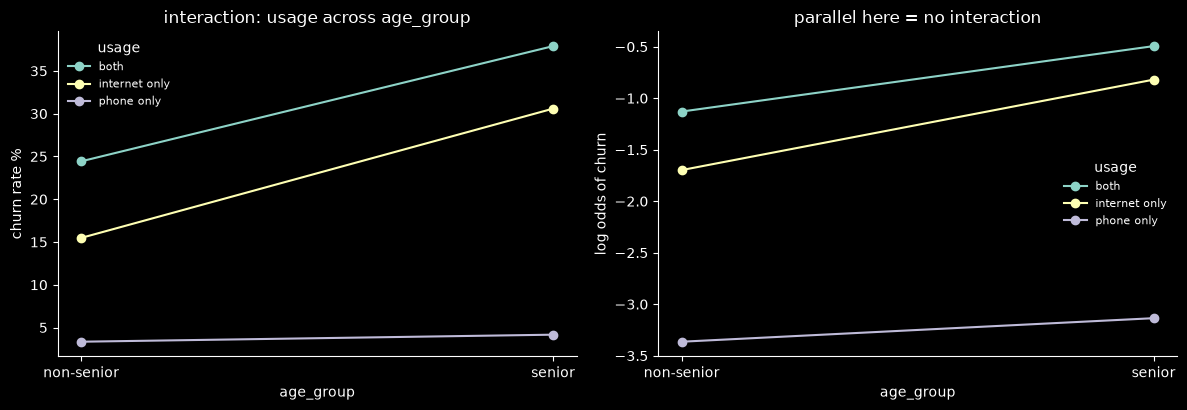

In [63]:
# Seniors churn more and may hold a different bundle - does the usage gap
# survive inside each age group?
query = """
SELECT
  CASE
    WHEN se.phone_service
    AND se.internet_service THEN 'both'
    WHEN se.phone_service THEN 'phone only'
    ELSE 'internet only'
  END AS usage,
  IF(d.age < 65, 'non-senior', 'senior') AS age_group,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__demographics` d USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  usage,
  age_group
"""

df = run_query(query)

rate_grid(df, rows="age_group", cols="usage")
stratified(df, group="usage", strata="age_group", a="both", b="phone only")
standardize(df, group="usage", strata="age_group")
model_compare(df, group="usage", strata="age_group")

plot_grid(df, rows="age_group", cols="usage");
plot_interaction(df, rows="age_group", cols="usage");

# Customer profiles

Three composite scores, each the sum of two binary indicators, so every score
runs 0 / 1 / 2 and is read as an ordinal:

| profile | = | + |
|---|---|---|
| **stability** | married | has at least one dependent |
| **trust** | on a committed contract (not month-to-month) | has referred at least one person |
| **engagement** | streams 2+ services | downloads 21+ GB a month |

The engagement cutoffs are median splits among internet customers (median
streaming count 2, median download 21 GB); the other four indicators are
natural yes/no. Engagement exists only where there is internet, so its cuts
run on internet customers and carry the 26.0% internet base rate rather than
the 21.2% overall one.

`trust` contains contract, so crossing it with the contract main effect would
be partly circular - that one cut uses the referral half of trust alone, and
says so.

## Profiles on their own

In [73]:
# Stability: married + has dependents, scored 0-2.
query = """
SELECT
  CASE
    CAST(d.married AS INT64) + IF(d.number_of_dependents > 0, 1, 0)
    WHEN 0 THEN '0 neither'
    WHEN 1 THEN '1 one of two'
    ELSE '2 both'
  END AS stability,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  stability
"""

df = run_query(query)
df["stability"] = band(df["stability"], ["0 neither", "1 one of two", "2 both"])
rate_table(df, group="stability", reference="0 neither")

stability   |   base 21.2%   |   5,992 customers, 1,272 churners

stability              rate % (95% CI)  % of cust  % of churn          diff pp (95% CI)   ratio   excess     p adj
------------------------------------------------------------------------------------------------------------------
2 both                  2.8 (2.1, 3.9)       21.1         2.8      -23.9 (-25.9, -22.0)   0.11x     -303   1.1e-70   n=1,267
1 one of two         25.4 (23.6, 27.3)       36.4        43.6         -1.4 (-3.9, +1.2)   0.95x      -30      0.29   n=2,183
0 neither            26.8 (25.1, 28.5)       42.4        53.5                         -       -        -         -   n=2,542
------------------------------------------------------------------------------------------------------------------
reference: 0 neither   omnibus chi2=326.2, dof=2, p=1.50e-71   * = n<100, directional only


In [74]:
# Trust: committed contract + has referred someone, scored 0-2.
query = """
SELECT
  CASE
    IF(se.contract != 'month-to-month', 1, 0) + IF(se.number_of_referrals > 0, 1, 0)
    WHEN 0 THEN '0 neither'
    WHEN 1 THEN '1 one of two'
    ELSE '2 both'
  END AS trust,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  trust
"""

df = run_query(query)
df["trust"] = band(df["trust"], ["0 neither", "1 one of two", "2 both"])
rate_table(df, group="trust", reference="0 neither")

trust   |   base 21.2%   |   5,992 customers, 1,272 churners

trust                  rate % (95% CI)  % of cust  % of churn          diff pp (95% CI)   ratio   excess     p adj
------------------------------------------------------------------------------------------------------------------
2 both                  5.9 (5.0, 7.0)       33.7         9.4      -35.4 (-38.0, -32.7)   0.14x     -714  5.1e-145   n=2,018
1 one of two         20.9 (19.3, 22.6)       39.9        39.3      -20.4 (-23.3, -17.4)   0.51x     -487   1.2e-43   n=2,392
0 neither            41.3 (38.9, 43.7)       26.4        51.3                         -       -        -         -   n=1,582
------------------------------------------------------------------------------------------------------------------
reference: 0 neither   omnibus chi2=664.1, dof=2, p=6.27e-145   * = n<100, directional only


In [75]:
# Engagement: streams 2+ services + downloads 21+ GB, scored 0-2.
# Internet customers only, so the base here is the internet base rate.
query = """
SELECT
  CASE
    IF(streams >= 2, 1, 0) + IF(gb >= 21, 1, 0)
    WHEN 0 THEN '0 low'
    WHEN 1 THEN '1 mixed'
    ELSE '2 high'
  END AS engagement,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners
FROM
  (
    SELECT
      st.churn_label,
      se.avg_monthly_gb_download AS gb,
      CAST(se.streaming_tv AS INT64) + CAST(se.streaming_movies AS INT64) + CAST(se.streaming_music AS INT64) AS streams
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.tenure_in_months > 3
      AND se.internet_service = TRUE
  )
GROUP BY
  engagement
"""

df = run_query(query)
df["engagement"] = band(df["engagement"], ["0 low", "1 mixed", "2 high"])
rate_table(df, group="engagement", reference="0 low")

engagement   |   base 26.0%   |   4,718 customers, 1,229 churners

engagement           rate % (95% CI)  % of cust  % of churn          diff pp (95% CI)   ratio   excess     p adj
----------------------------------------------------------------------------------------------------------------
2 high             24.1 (21.9, 26.5)       27.8        25.8         -3.7 (-7.3, -0.2)   0.87x      -49     0.075   n=1,313
1 mixed            26.3 (24.5, 28.1)       49.1        49.6         -1.6 (-4.9, +1.6)   0.94x      -37      0.33   n=2,318
0 low              27.9 (25.3, 30.6)       23.0        24.7                         -       -        -         -   n=1,087
----------------------------------------------------------------------------------------------------------------
reference: 0 low   omnibus chi2=4.4, dof=2, p=1.10e-01   * = n<100, directional only


## Age x profiles

churn rate: age_group x stability   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

stability       non-senior       senior   |         all 
--------------------------------------------------------
0 neither     23.9 (2,101)   40.6 (441)   | 26.8 (2,542) 
1 one of two  22.8 (1,696)   34.5 (487)   | 25.4 (2,183) 
2 both         2.6 (1,207)     8.3 (60)*  | 2.8 (1,267) 
--------------------------------------------------------
all           18.4 (5,004)   35.6 (988)   | 21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across stability); last line = share of all customers

stability       non-senior       senior   |         all 
--------------------------------------------------------
0 neither             42.0         44.6   |       42.4  
1 one of two          33.9         49.3   |       36.4  
2 both                24.1          6.1   |       21.1  
--------------------------------------------------------
all         

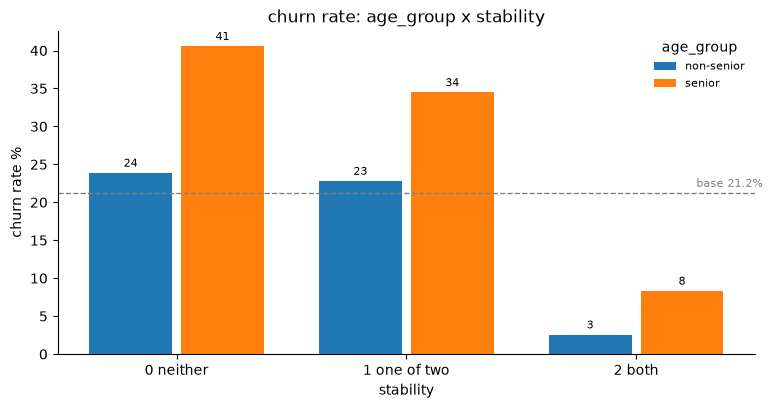

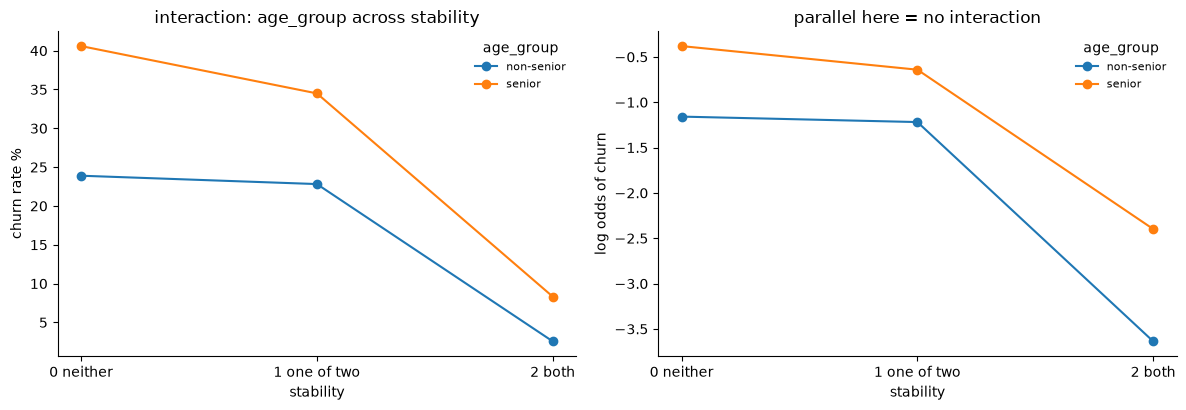

In [76]:
# Does the senior penalty hold inside every stability profile?
query = """
SELECT
  IF(d.age < 65, 'non-senior', 'senior') AS age_group,
  CASE
    CAST(d.married AS INT64) + IF(d.number_of_dependents > 0, 1, 0)
    WHEN 0 THEN '0 neither'
    WHEN 1 THEN '1 one of two'
    ELSE '2 both'
  END AS stability,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  age_group,
  stability
"""

df = run_query(query)
df["stability"] = band(df["stability"], ["0 neither", "1 one of two", "2 both"])

rate_grid(df, rows="stability", cols="age_group")
stratified(df, group="age_group", strata="stability", a="senior", b="non-senior")
standardize(df, group="age_group", strata="stability")
model_compare(df, group="age_group", strata="stability")

plot_grid(df, rows="stability", cols="age_group");
plot_interaction(df, rows="stability", cols="age_group");

churn rate: age_group x trust   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

trust           non-senior       senior   |         all 
--------------------------------------------------------
0 neither     34.6 (1,357)   81.3 (225)   | 41.3 (1,582) 
1 one of two  18.0 (1,945)   33.6 (447)   | 20.9 (2,392) 
2 both         5.9 (1,702)    6.0 (316)   | 5.9 (2,018) 
--------------------------------------------------------
all           18.4 (5,004)   35.6 (988)   | 21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across trust); last line = share of all customers

trust           non-senior       senior   |         all 
--------------------------------------------------------
0 neither             27.1         22.8   |       26.4  
1 one of two          38.9         45.2   |       39.9  
2 both                34.0         32.0   |       33.7  
--------------------------------------------------------
all                 

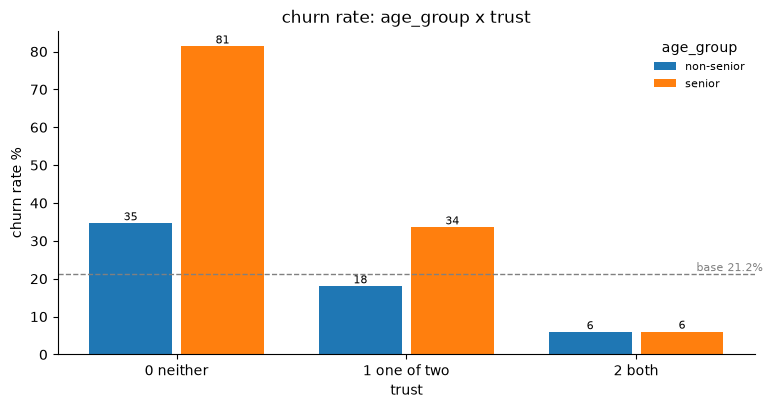

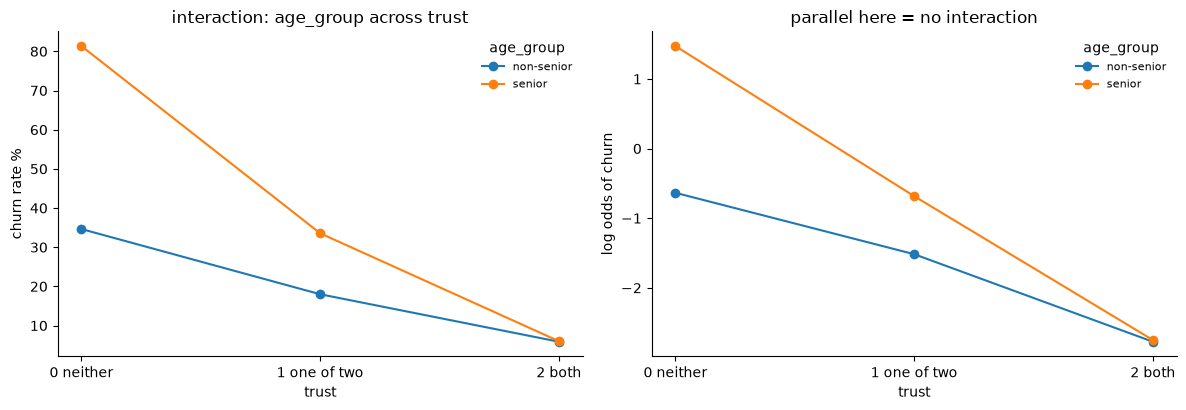

In [77]:
# Does the senior penalty hold inside every trust profile?
query = """
SELECT
  IF(d.age < 65, 'non-senior', 'senior') AS age_group,
  CASE
    IF(se.contract != 'month-to-month', 1, 0) + IF(se.number_of_referrals > 0, 1, 0)
    WHEN 0 THEN '0 neither'
    WHEN 1 THEN '1 one of two'
    ELSE '2 both'
  END AS trust,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__demographics` d USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  age_group,
  trust
"""

df = run_query(query)
df["trust"] = band(df["trust"], ["0 neither", "1 one of two", "2 both"])

rate_grid(df, rows="trust", cols="age_group")
stratified(df, group="age_group", strata="trust", a="senior", b="non-senior")
standardize(df, group="age_group", strata="trust")
model_compare(df, group="age_group", strata="trust")

plot_grid(df, rows="trust", cols="age_group");
plot_interaction(df, rows="trust", cols="age_group");

churn rate: age_group x engagement   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

engagement    non-senior       senior   |         all 
------------------------------------------------------
0 low         23.8 (798)   39.1 (289)   | 27.9 (1,087) 
1 mixed     23.6 (1,825)   36.1 (493)   | 26.3 (2,318) 
2 high      22.3 (1,155)   37.3 (158)   | 24.1 (1,313) 
------------------------------------------------------
all         23.3 (3,778)   37.2 (940)   | 26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across engagement); last line = share of all customers

engagement    non-senior       senior   |         all 
------------------------------------------------------
0 low               21.1         30.7   |       23.0  
1 mixed             48.3         52.4   |       49.1  
2 high              30.6         16.8   |       27.8  
------------------------------------------------------
all                 80.1         19

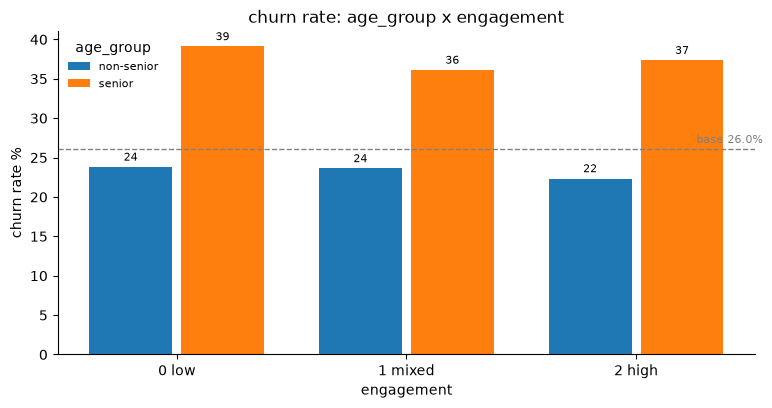

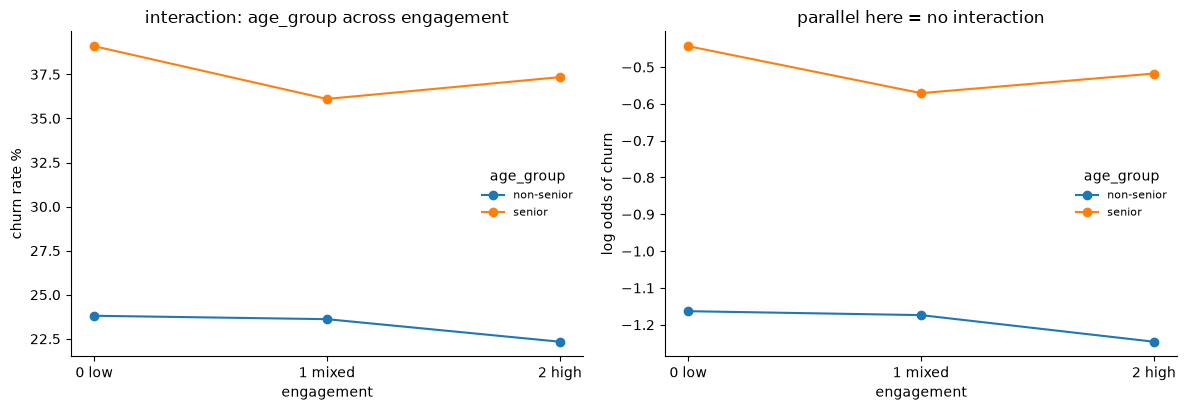

In [78]:
# Does the senior penalty hold at every level of engagement? Internet customers only.
query = """
SELECT
  age_group,
  CASE
    IF(streams >= 2, 1, 0) + IF(gb >= 21, 1, 0)
    WHEN 0 THEN '0 low'
    WHEN 1 THEN '1 mixed'
    ELSE '2 high'
  END AS engagement,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners
FROM
  (
    SELECT
      IF(d.age < 65, 'non-senior', 'senior') AS age_group,
      st.churn_label,
      se.avg_monthly_gb_download AS gb,
      CAST(se.streaming_tv AS INT64) + CAST(se.streaming_movies AS INT64) + CAST(se.streaming_music AS INT64) AS streams
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
      JOIN `dbt_dev.stg_telco__demographics` d USING (customer_id)
    WHERE
      se.tenure_in_months > 3
      AND se.internet_service = TRUE
  )
GROUP BY
  age_group,
  engagement
"""

df = run_query(query)
df["engagement"] = band(df["engagement"], ["0 low", "1 mixed", "2 high"])

rate_grid(df, rows="engagement", cols="age_group")
stratified(df, group="age_group", strata="engagement", a="senior", b="non-senior")
standardize(df, group="age_group", strata="engagement")
model_compare(df, group="age_group", strata="engagement")

plot_grid(df, rows="engagement", cols="age_group");
plot_interaction(df, rows="engagement", cols="age_group");

## Contract x profiles

churn rate: contract x stability   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

stability      month-to-month        one year        two year   |            all 
---------------------------------------------------------------------------------
0 neither        42.9 (1,392)      11.1 (605)       3.1 (545)   |   26.8 (2,542) 
1 one of two       50.8 (840)      15.8 (612)       4.2 (731)   |   25.4 (2,183) 
2 both              9.6 (375)       0.0 (307)       0.0 (585)   |    2.8 (1,267) 
---------------------------------------------------------------------------------
all              40.7 (2,607)    10.8 (1,524)     2.6 (1,861)   |   21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across stability); last line = share of all customers

stability      month-to-month        one year        two year   |            all 
---------------------------------------------------------------------------------
0 neither          

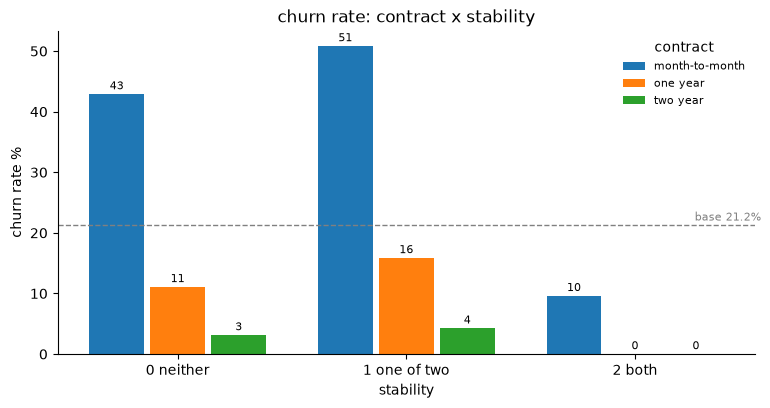

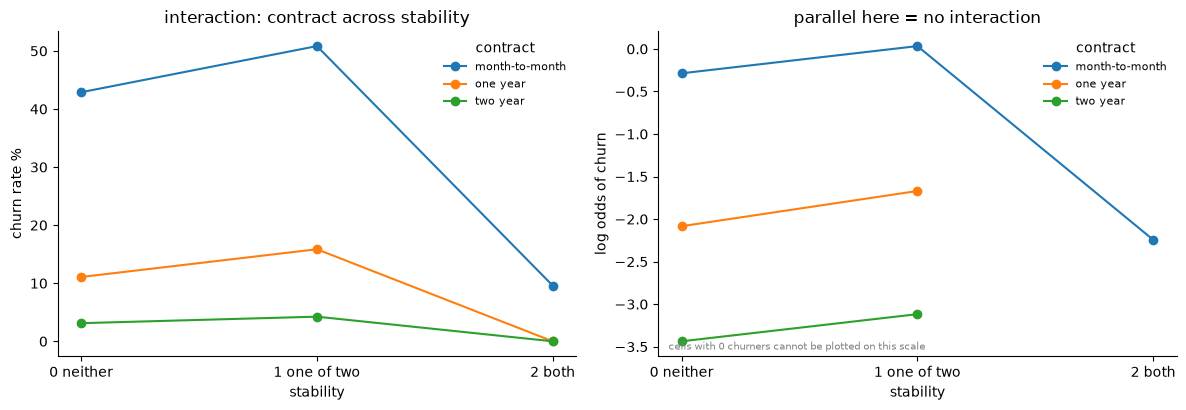

In [79]:
# Does the contract gap hold inside every stability profile?
query = """
SELECT
  se.contract,
  CASE
    CAST(d.married AS INT64) + IF(d.number_of_dependents > 0, 1, 0)
    WHEN 0 THEN '0 neither'
    WHEN 1 THEN '1 one of two'
    ELSE '2 both'
  END AS stability,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__demographics` d USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  se.contract,
  stability
"""

df = run_query(query)
df["stability"] = band(df["stability"], ["0 neither", "1 one of two", "2 both"])

rate_grid(df, rows="stability", cols="contract")
stratified(df, group="contract", strata="stability", a="month-to-month", b="two year")
standardize(df, group="contract", strata="stability")
model_compare(df, group="contract", strata="stability")

plot_grid(df, rows="stability", cols="contract");
plot_interaction(df, rows="stability", cols="contract");

churn rate: contract x trust_referral   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

trust_referral   month-to-month        one year        two year   |            all 
-----------------------------------------------------------------------------------
no referral        41.3 (1,582)      10.1 (703)       3.3 (664)   |   25.3 (2,949) 
referred           39.7 (1,025)      11.3 (821)     2.2 (1,197)   |   17.3 (3,043) 
-----------------------------------------------------------------------------------
all                40.7 (2,607)    10.8 (1,524)     2.6 (1,861)   |   21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across trust_referral); last line = share of all customers

trust_referral   month-to-month        one year        two year   |            all 
-----------------------------------------------------------------------------------
no referral                60.7            46.1            35.7   |        

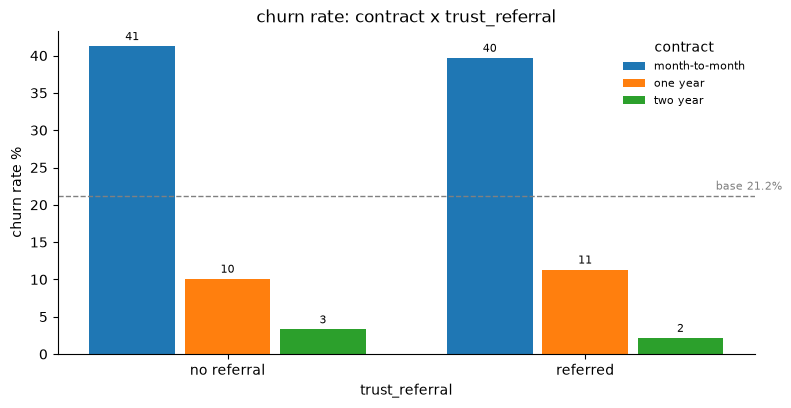

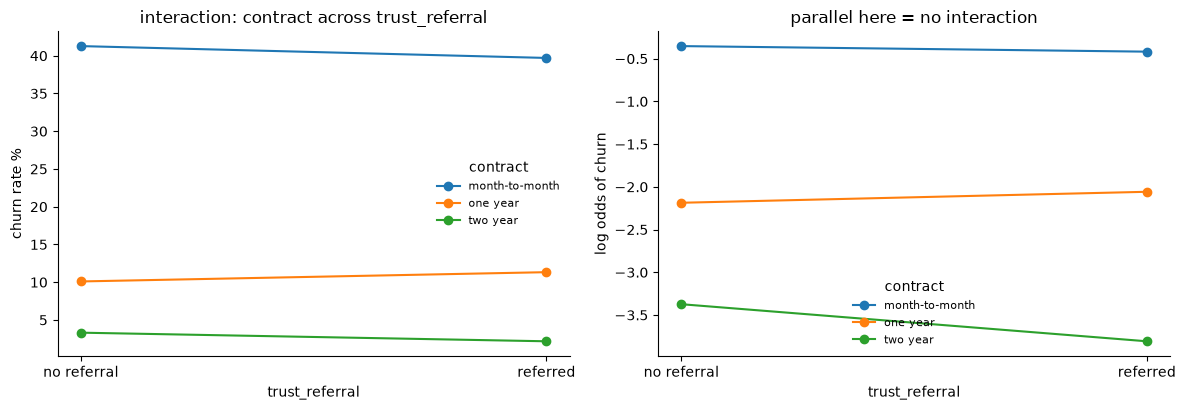

In [80]:
# Contract is half of the trust score, so crossing the two as defined would be
# circular. The trust axis here is its other half alone: has the customer
# referred anyone.
query = """
SELECT
  se.contract,
  IF(se.number_of_referrals > 0, 'referred', 'no referral') AS trust_referral,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  se.contract,
  trust_referral
"""

df = run_query(query)

rate_grid(df, rows="trust_referral", cols="contract")
stratified(df, group="contract", strata="trust_referral", a="month-to-month", b="two year")
standardize(df, group="contract", strata="trust_referral")
model_compare(df, group="contract", strata="trust_referral")

plot_grid(df, rows="trust_referral", cols="contract");
plot_interaction(df, rows="trust_referral", cols="contract");

churn rate: contract x engagement   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

engagement   month-to-month        one year        two year   |            all 
-------------------------------------------------------------------------------
0 low            44.5 (634)       6.8 (251)       2.0 (202)   |   27.9 (1,087) 
1 mixed        43.0 (1,185)      13.7 (561)       3.8 (572)   |   26.3 (2,318) 
2 high           47.4 (500)      17.4 (363)       3.8 (450)   |   24.1 (1,313) 
-------------------------------------------------------------------------------
all            44.4 (2,319)    13.4 (1,175)     3.5 (1,224)   |   26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across engagement); last line = share of all customers

engagement   month-to-month        one year        two year   |            all 
-------------------------------------------------------------------------------
0 low                  27.3        

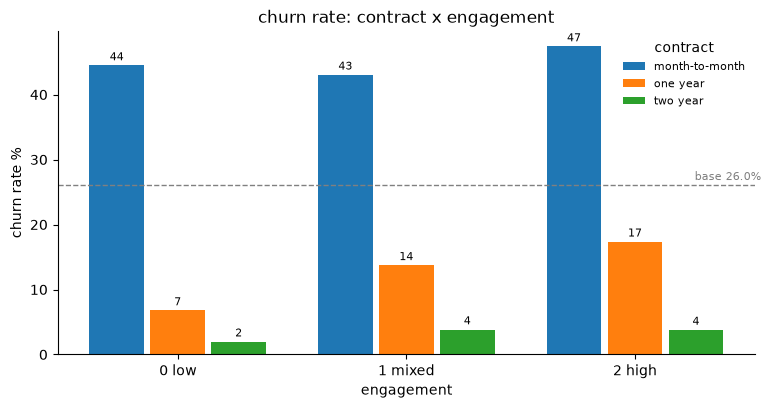

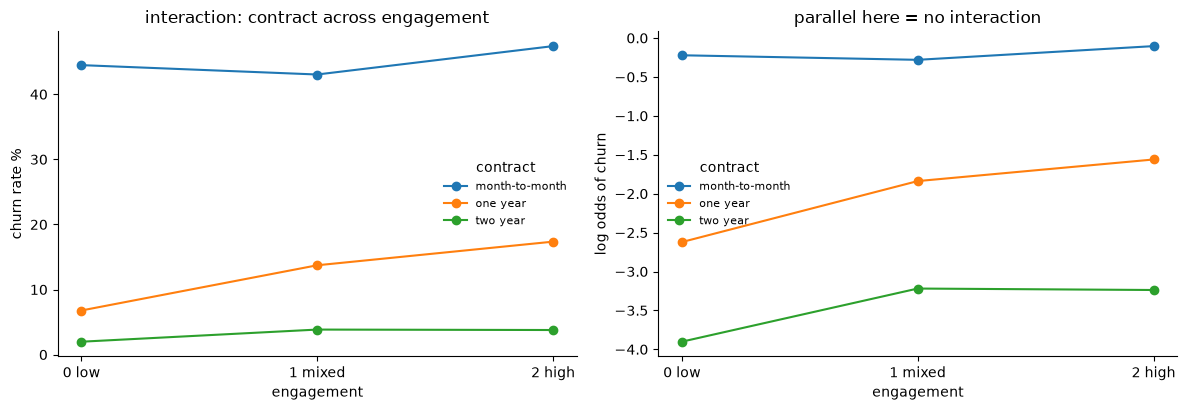

In [81]:
# Does the contract gap hold at every level of engagement? Internet customers only.
query = """
SELECT
  contract,
  CASE
    IF(streams >= 2, 1, 0) + IF(gb >= 21, 1, 0)
    WHEN 0 THEN '0 low'
    WHEN 1 THEN '1 mixed'
    ELSE '2 high'
  END AS engagement,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners
FROM
  (
    SELECT
      se.contract,
      st.churn_label,
      se.avg_monthly_gb_download AS gb,
      CAST(se.streaming_tv AS INT64) + CAST(se.streaming_movies AS INT64) + CAST(se.streaming_music AS INT64) AS streams
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.tenure_in_months > 3
      AND se.internet_service = TRUE
  )
GROUP BY
  contract,
  engagement
"""

df = run_query(query)
df["engagement"] = band(df["engagement"], ["0 low", "1 mixed", "2 high"])

rate_grid(df, rows="engagement", cols="contract")
stratified(df, group="contract", strata="engagement", a="month-to-month", b="two year")
standardize(df, group="contract", strata="engagement")
model_compare(df, group="contract", strata="engagement")

plot_grid(df, rows="engagement", cols="contract");
plot_interaction(df, rows="engagement", cols="contract");

## Internet type x profiles

churn rate: internet_type x stability   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

stability            cable          dsl  fiber optic   |         all 
---------------------------------------------------------------------
0 neither       22.7 (273)   17.3 (594) 42.0 (1,175)   | 32.2 (2,042) 
1 one of two    22.9 (279)   12.6 (515) 39.0 (1,051)   | 29.2 (1,845) 
2 both           4.9 (142)    4.3 (302)    3.1 (387)   |   3.9 (831) 
---------------------------------------------------------------------
all             19.2 (694) 12.8 (1,411) 35.0 (2,613)   | 26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across stability); last line = share of all customers

stability            cable          dsl  fiber optic   |         all 
---------------------------------------------------------------------
0 neither             39.3         42.1         45.0   |       43.3  
1 one of two          40.2         36.5         4

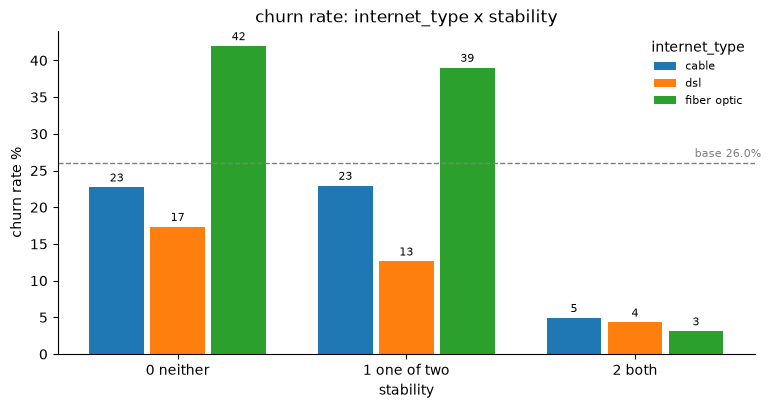

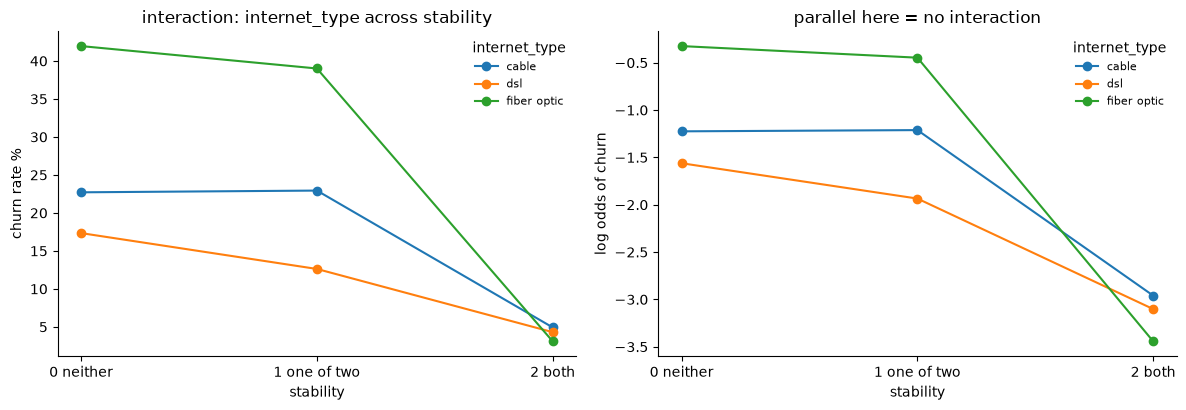

In [82]:
# Does the fiber penalty hold inside every stability profile?
query = """
SELECT
  se.internet_type,
  CASE
    CAST(d.married AS INT64) + IF(d.number_of_dependents > 0, 1, 0)
    WHEN 0 THEN '0 neither'
    WHEN 1 THEN '1 one of two'
    ELSE '2 both'
  END AS stability,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__demographics` d USING (customer_id)
WHERE
  se.tenure_in_months > 3
  AND se.internet_service = TRUE
GROUP BY
  se.internet_type,
  stability
"""

df = run_query(query)
df["stability"] = band(df["stability"], ["0 neither", "1 one of two", "2 both"])

rate_grid(df, rows="stability", cols="internet_type")
stratified(df, group="internet_type", strata="stability", a="fiber optic", b="dsl")
standardize(df, group="internet_type", strata="stability")
model_compare(df, group="internet_type", strata="stability")

plot_grid(df, rows="stability", cols="internet_type");
plot_interaction(df, rows="stability", cols="internet_type");

churn rate: internet_type x trust   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

trust                cable          dsl  fiber optic   |         all 
---------------------------------------------------------------------
0 neither       36.0 (172)   26.7 (337)   54.7 (879)   | 45.6 (1,388) 
1 one of two    19.5 (267)   11.8 (570) 35.2 (1,032)   | 25.8 (1,869) 
2 both           7.5 (255)    4.8 (504)   10.1 (702)   | 7.8 (1,461) 
---------------------------------------------------------------------
all             19.2 (694) 12.8 (1,411) 35.0 (2,613)   | 26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across trust); last line = share of all customers

trust                cable          dsl  fiber optic   |         all 
---------------------------------------------------------------------
0 neither             24.8         23.9         33.6   |       29.4  
1 one of two          38.5         40.4         39.5   | 

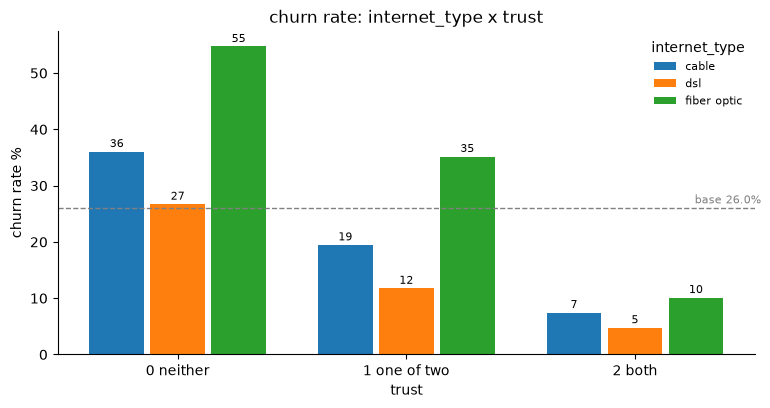

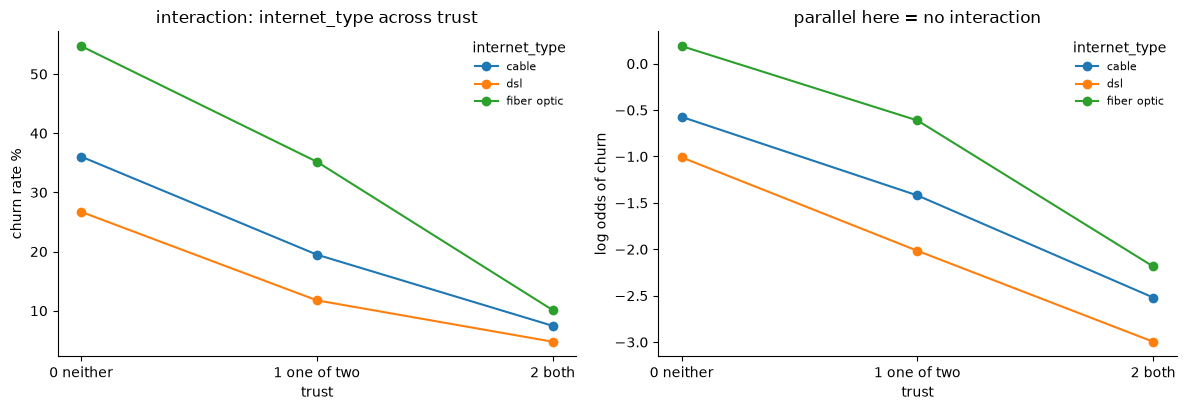

In [83]:
# Does the fiber penalty hold inside every trust profile?
query = """
SELECT
  se.internet_type,
  CASE
    IF(se.contract != 'month-to-month', 1, 0) + IF(se.number_of_referrals > 0, 1, 0)
    WHEN 0 THEN '0 neither'
    WHEN 1 THEN '1 one of two'
    ELSE '2 both'
  END AS trust,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
  AND se.internet_service = TRUE
GROUP BY
  se.internet_type,
  trust
"""

df = run_query(query)
df["trust"] = band(df["trust"], ["0 neither", "1 one of two", "2 both"])

rate_grid(df, rows="trust", cols="internet_type")
stratified(df, group="internet_type", strata="trust", a="fiber optic", b="dsl")
standardize(df, group="internet_type", strata="trust")
model_compare(df, group="internet_type", strata="trust")

plot_grid(df, rows="trust", cols="internet_type");
plot_interaction(df, rows="trust", cols="internet_type");

churn rate: internet_type x engagement   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

engagement         cable          dsl  fiber optic   |         all 
-------------------------------------------------------------------
0 low         20.7 (174)   14.6 (362)   38.8 (551)   | 27.9 (1,087) 
1 mixed       20.4 (334)   13.7 (701) 34.7 (1,283)   | 26.3 (2,318) 
2 high        15.6 (186)    9.2 (348)   32.9 (779)   | 24.1 (1,313) 
-------------------------------------------------------------------
all           19.2 (694) 12.8 (1,411) 35.0 (2,613)   | 26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across engagement); last line = share of all customers

engagement         cable          dsl  fiber optic   |         all 
-------------------------------------------------------------------
0 low               25.1         25.7         21.1   |       23.0  
1 mixed             48.1         49.7         49.1   |       49.1 

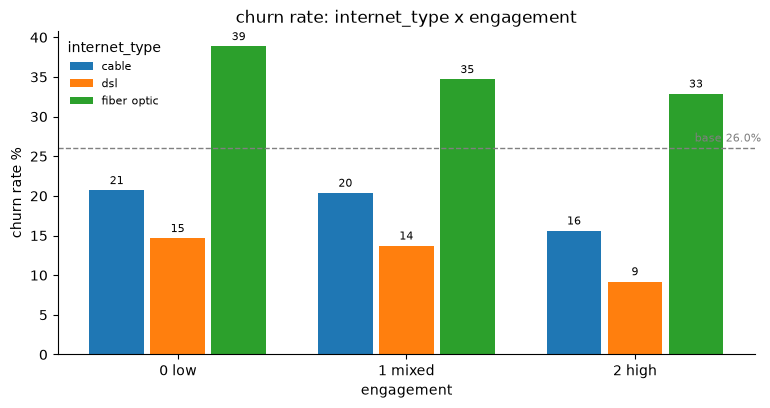

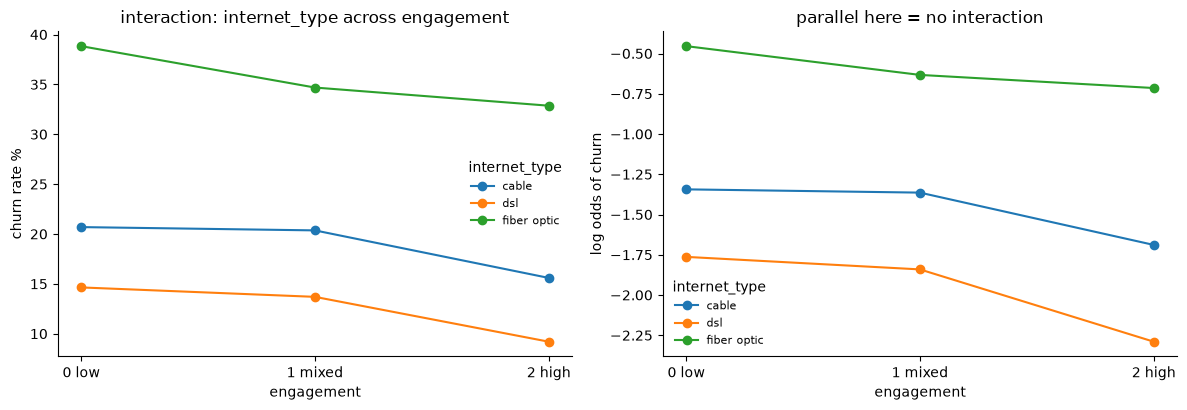

In [84]:
# Does the fiber penalty hold at every level of engagement? If fiber churn were
# really heavy usage, the gap should shrink inside the high-engagement band.
query = """
SELECT
  internet_type,
  CASE
    IF(streams >= 2, 1, 0) + IF(gb >= 21, 1, 0)
    WHEN 0 THEN '0 low'
    WHEN 1 THEN '1 mixed'
    ELSE '2 high'
  END AS engagement,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners
FROM
  (
    SELECT
      se.internet_type,
      st.churn_label,
      se.avg_monthly_gb_download AS gb,
      CAST(se.streaming_tv AS INT64) + CAST(se.streaming_movies AS INT64) + CAST(se.streaming_music AS INT64) AS streams
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.tenure_in_months > 3
      AND se.internet_service = TRUE
  )
GROUP BY
  internet_type,
  engagement
"""

df = run_query(query)
df["engagement"] = band(df["engagement"], ["0 low", "1 mixed", "2 high"])

rate_grid(df, rows="engagement", cols="internet_type")
stratified(df, group="internet_type", strata="engagement", a="fiber optic", b="dsl")
standardize(df, group="internet_type", strata="engagement")
model_compare(df, group="internet_type", strata="engagement")

plot_grid(df, rows="engagement", cols="internet_type");
plot_interaction(df, rows="engagement", cols="internet_type");

## Payment method x profiles

churn rate: payment x stability   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

stability             card     non-card   |         all 
--------------------------------------------------------
0 neither       16.3 (968) 33.2 (1,574)   | 26.8 (2,542) 
1 one of two    12.5 (823) 33.2 (1,360)   | 25.4 (2,183) 
2 both           1.7 (600)    3.9 (667)   | 2.8 (1,267) 
--------------------------------------------------------
all           11.3 (2,391) 27.8 (3,601)   | 21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across stability); last line = share of all customers

stability             card     non-card   |         all 
--------------------------------------------------------
0 neither             40.5         43.7   |       42.4  
1 one of two          34.4         37.8   |       36.4  
2 both                25.1         18.5   |       21.1  
--------------------------------------------------------
all           

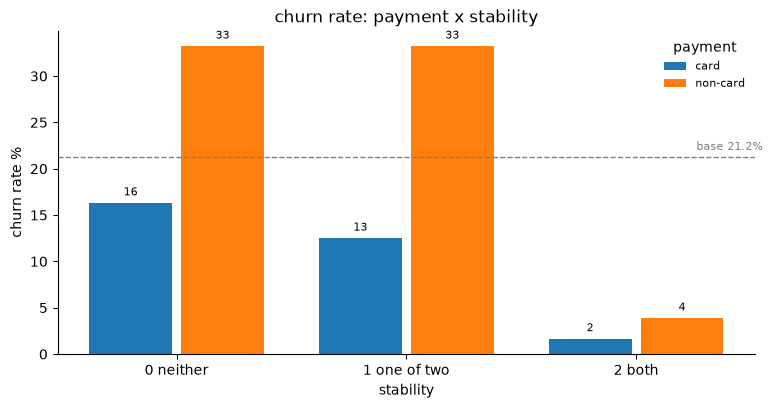

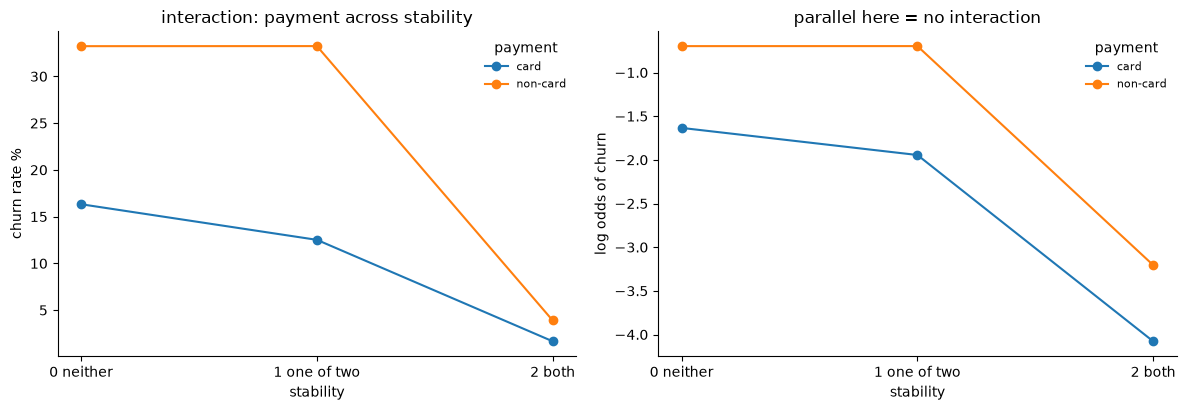

In [85]:
# Does the card advantage hold inside every stability profile?
query = """
SELECT
  IF(
    se.payment_method = 'credit card',
    'card',
    'non-card'
  ) AS payment,
  CASE
    CAST(d.married AS INT64) + IF(d.number_of_dependents > 0, 1, 0)
    WHEN 0 THEN '0 neither'
    WHEN 1 THEN '1 one of two'
    ELSE '2 both'
  END AS stability,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__demographics` d USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  payment,
  stability
"""

df = run_query(query)
df["stability"] = band(df["stability"], ["0 neither", "1 one of two", "2 both"])

rate_grid(df, rows="stability", cols="payment")
stratified(df, group="payment", strata="stability", a="non-card", b="card")
standardize(df, group="payment", strata="stability")
model_compare(df, group="payment", strata="stability")

plot_grid(df, rows="stability", cols="payment");
plot_interaction(df, rows="stability", cols="payment");

churn rate: payment x trust   |   base 21.2%   |   5,992 customers, 1,272 churners

churn rate: rate% (n)   * = n<100

trust                 card     non-card   |         all 
--------------------------------------------------------
0 neither       27.3 (520) 48.1 (1,062)   | 41.3 (1,582) 
1 one of two    10.5 (922) 27.4 (1,470)   | 20.9 (2,392) 
2 both           3.4 (949)  8.1 (1,069)   | 5.9 (2,018) 
--------------------------------------------------------
all           11.3 (2,391) 27.8 (3,601)   | 21.2 (5,992) 

customer mix %: each column sums to 100 (how the group spreads across trust); last line = share of all customers

trust                 card     non-card   |         all 
--------------------------------------------------------
0 neither             21.7         29.5   |       26.4  
1 one of two          38.6         40.8   |       39.9  
2 both                39.7         29.7   |       33.7  
--------------------------------------------------------
all                   

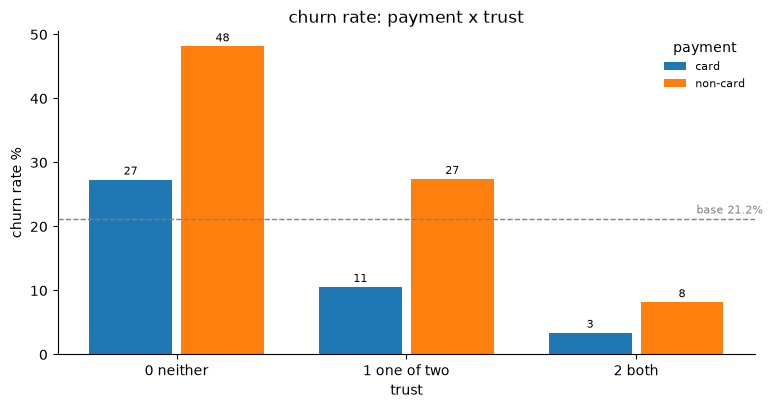

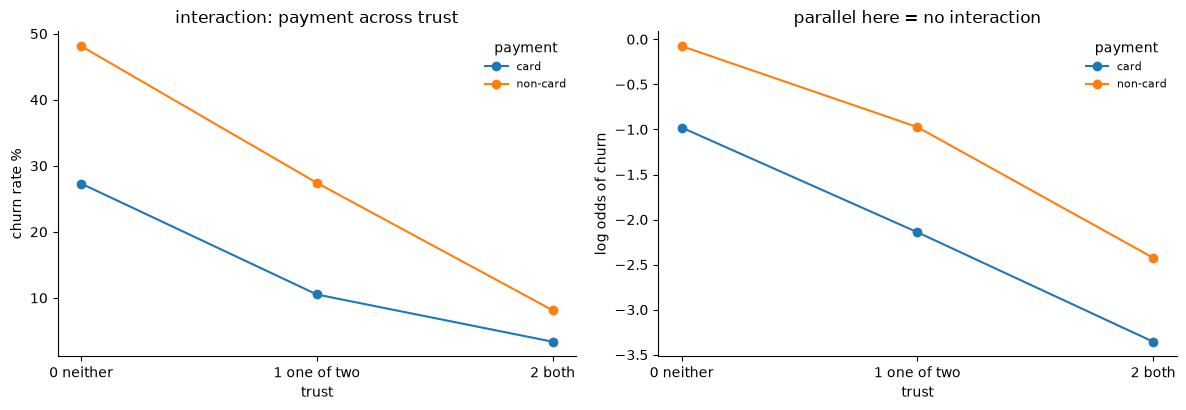

In [86]:
# Does the card advantage hold inside every trust profile?
query = """
SELECT
  IF(
    se.payment_method = 'credit card',
    'card',
    'non-card'
  ) AS payment,
  CASE
    IF(se.contract != 'month-to-month', 1, 0) + IF(se.number_of_referrals > 0, 1, 0)
    WHEN 0 THEN '0 neither'
    WHEN 1 THEN '1 one of two'
    ELSE '2 both'
  END AS trust,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  payment,
  trust
"""

df = run_query(query)
df["trust"] = band(df["trust"], ["0 neither", "1 one of two", "2 both"])

rate_grid(df, rows="trust", cols="payment")
stratified(df, group="payment", strata="trust", a="non-card", b="card")
standardize(df, group="payment", strata="trust")
model_compare(df, group="payment", strata="trust")

plot_grid(df, rows="trust", cols="payment");
plot_interaction(df, rows="trust", cols="payment");

churn rate: payment x engagement   |   base 26.0%   |   4,718 customers, 1,229 churners

churn rate: rate% (n)   * = n<100

engagement          card     non-card   |         all 
------------------------------------------------------
0 low         16.4 (383)   34.1 (704)   | 27.9 (1,087) 
1 mixed       15.8 (799) 31.8 (1,519)   | 26.3 (2,318) 
2 high        14.2 (436)   29.1 (877)   | 24.1 (1,313) 
------------------------------------------------------
all         15.5 (1,618) 31.5 (3,100)   | 26.0 (4,718) 

customer mix %: each column sums to 100 (how the group spreads across engagement); last line = share of all customers

engagement          card     non-card   |         all 
------------------------------------------------------
0 low               23.7         22.7   |       23.0  
1 mixed             49.4         49.0   |       49.1  
2 high              26.9         28.3   |       27.8  
------------------------------------------------------
all                 34.3         65.7

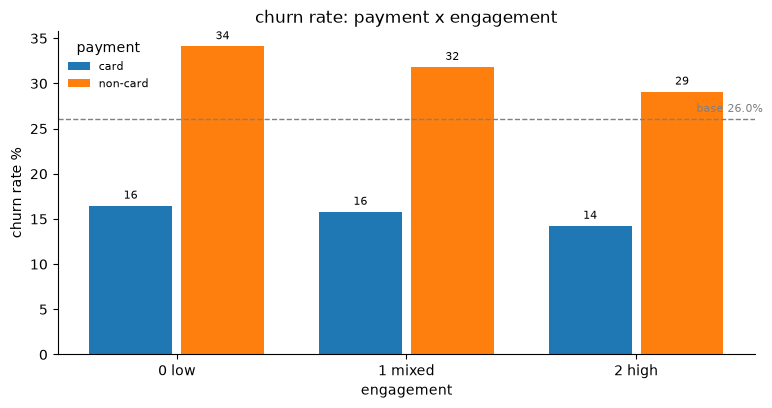

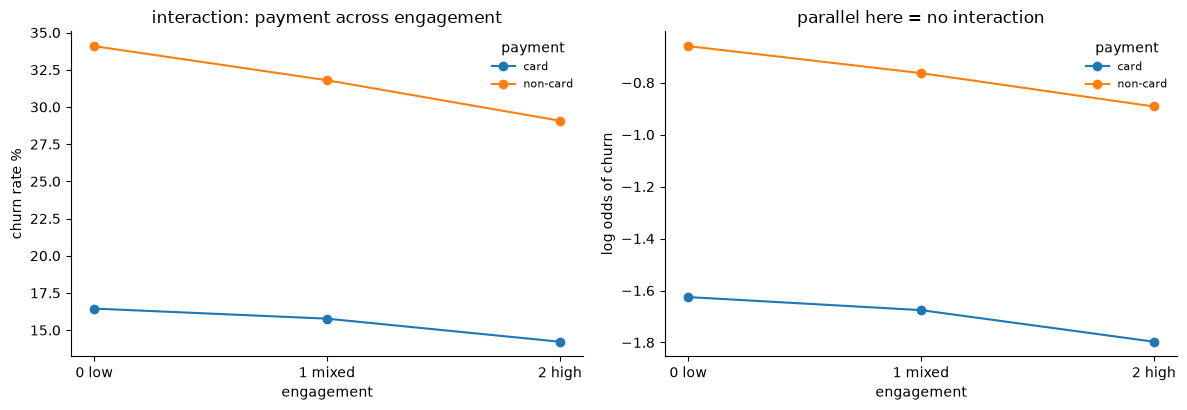

In [87]:
# Does the card advantage hold at every level of engagement? Internet customers only.
query = """
SELECT
  payment,
  CASE
    IF(streams >= 2, 1, 0) + IF(gb >= 21, 1, 0)
    WHEN 0 THEN '0 low'
    WHEN 1 THEN '1 mixed'
    ELSE '2 high'
  END AS engagement,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners
FROM
  (
    SELECT
      IF(
        se.payment_method = 'credit card',
        'card',
        'non-card'
      ) AS payment,
      st.churn_label,
      se.avg_monthly_gb_download AS gb,
      CAST(se.streaming_tv AS INT64) + CAST(se.streaming_movies AS INT64) + CAST(se.streaming_music AS INT64) AS streams
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.tenure_in_months > 3
      AND se.internet_service = TRUE
  )
GROUP BY
  payment,
  engagement
"""

df = run_query(query)
df["engagement"] = band(df["engagement"], ["0 low", "1 mixed", "2 high"])

rate_grid(df, rows="engagement", cols="payment")
stratified(df, group="payment", strata="engagement", a="non-card", b="card")
standardize(df, group="payment", strata="engagement")
model_compare(df, group="payment", strata="engagement")

plot_grid(df, rows="engagement", cols="payment");
plot_interaction(df, rows="engagement", cols="payment");